## Setup                                                                              

In [1]:
# import tools

# standard library
import os
import types
import sys
import inspect
import yaml
import time
#import ipyparallel as ipp
import datetime

# scientific stack
import numpy as np
#import jax.numpy as jnp
import scipy
from scipy.stats import linregress
from scipy.integrate import simpson
from scipy.ndimage import gaussian_filter1d
from scipy.interpolate import CubicSpline, interp1d
from scipy.optimize import curve_fit
import pandas as pd

# cosmology
#import astropy
#import astropy.units as units
#from astropy.cosmology import LambdaCDM, w0waCDM
import pyccl as ccl
import camb
from camb import model, initialpower
#import classy
#from cosmopower_jax.cosmopower_jax import CosmoPowerJAX as CPJ
import warnings
#warnings.filterwarnings('ignore')
#import jax; jax.config.update('jax_platform_name', 'cpu')
#import desilike
#from desilike.theories.galaxy_clustering import StandardPowerSpectrumTemplate
#from desilike.likelihoods.base import BaseLikelihood
#from desilike.likelihoods.base import BaseGaussianLikelihood
#from desilike.likelihoods.base import ObservablesGaussianLikelihood
#from desilike.fisher import Fisher

# plotting
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display, Markdown, HTML
#from tabulate import tabulate

# inference / sampling
#import cobaya
#from cobaya.run import run as cobaya_run
#from cobaya.likelihood import Likelihood
#from cobaya.model import get_model
#from cobaya_utilities import fisher
import getdist
import getdist.plots as plots
from getdist import plots, MCSamples
from getdist.mcsamples import MCSamples
from getdist.mcsamples import loadMCSamples
from getdist.gaussian_mixtures import GaussianND

# notebook only (remove if this becomes a .py module)
%matplotlib inline

import logging
import warnings

# Suppress Matplotlib font warning logs
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

# Or suppress warnings generally
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')

In [2]:
# import custom helper functions and classes

# functions
from functions_and_classes import calculate_and_plot_Cls
from functions_and_classes import build_tracers_from_data
from functions_and_classes import build_tracer_dict
from functions_and_classes import build_noise_dict
from functions_and_classes import build_spectra_dict
from functions_and_classes import build_data_vector
from functions_and_classes import create_simplified_desired_pairs
from functions_and_classes import build_covariance_from_data
from functions_and_classes import plot_covariance_matrix
from functions_and_classes import plot_spectra_from_dict
from functions_and_classes import make_Pk2D
from functions_and_classes import predict_linear_Pk
from functions_and_classes import predict_boost_Pk
from functions_and_classes import project_fisher_matrix
from functions_and_classes import get_partial_derivative
from functions_and_classes import sample_fisher_with_uniform_priors
from functions_and_classes import plot_Fisher_from_matrices

# classes
from functions_and_classes import ForecastMap
from functions_and_classes import CovarianceMatrix
from functions_and_classes import FisherForecaster

LOADING FILE: /global/u2/l/lialubit/DESIxSO/functions_and_classes.py


In [3]:
# cosmologies and priors -- all values from DESI DR2 Chains, DESI+CMB or, if available, DESI+CMB+DESY5

# flat LCDM
# values taken from Planck 2018 TT, TE, EE+lowE
Omega_b = 0.04807
Omega_c = 0.2532
Omega_k = 0
w0 = -1
wa = 0
h = 0.6817
n_s = 0.9693
A_s = 2.122e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved LCDM
Omega_b = 0.04735
Omega_c = 0.2547
Omega_k = 0.00231
w0 = -1
wa = 0
h = 0.6850
n_s = 0.9649
A_s = 2.115e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
curved_LCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# flat wCDM
Omega_b = 0.04929
Omega_c = 0.2591
Omega_k = 0
w0 = -0.9706
wa = 0
h = 0.6734
n_s = 0.9699
A_s = 2.127e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_wCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})


# flat w0wa
Omega_b = 0.04991
Omega_c = 0.2676
Omega_k = 0
w0 = -0.7521
wa = -0.8611
h = 0.6674
n_s = 0.9654
A_s = 2.094e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
flat_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# curved w0wa
Omega_b = 0.04974
Omega_c = 0.2680
Omega_k = 0.00077
w0 = -0.7621
wa = -0.8073
h = 0.6682
n_s = 0.9644
A_s = 2.095e-9
Neff = 3.046 # SM prediction
m_nu = 0.06
T_CMB = 2.7255
curved_w0waCDM_cosmology = ccl.Cosmology(Omega_c=Omega_c, Omega_b=Omega_b, Omega_k=Omega_k, h=h, A_s=A_s, n_s=n_s, w0=w0, wa=wa, T_CMB=T_CMB,
                               Neff = Neff, m_nu = m_nu, transfer_function='boltzmann_camb',
                               extra_parameters={"camb": {"dark_energy_model": "ppf"}})

# define prior
# all priors taken from Planck unless otherwise stated (https://arxiv.org/pdf/1303.5076)
uniform_prior = {
    'Omega_c': (0.1, 0.9), # not Planck prior given, prior self chosen
    'wa': (-3, 3),         # wider than Planck prior by 1 in each direction
    'w0': (-3, -0.3),
    'A_s': (1.48797e-9, 5.45981e-9),
    'h': (0.2, 1.0),
    'Omega_b': (0.011, 0.221),
    'n_s': (0.9, 1.1),
    'Omega_k': (-0.3, 0.3),
    'm_nu': (0, 5)
}

## Data and Noise

In [ ]:
# TESTING
# DESI DES sky overlap: https://watermark02.silverchair.com/stad2221.pdf?token=AQECAHi208BE49Ooan9kkhW_Ercy7Dm3ZL_9Cf3qfKAc485ysgAAA1UwggNRBgkqhkiG9w0BBwagggNCMIIDPgIBADCCAzcGCSqGSIb3DQEHATAeBglghkgBZQMEAS4wEQQMPF_1Rf3PlLw4g5VBAgEQgIIDCIlykzq-IzVjb7Q-kkK-E_5umppOPSrMHOM4UcfgCovcPTCkOTtlNtDEuRTFA8zh7iBGNGsDnd-8gGRpt2fMeYXMDfYdJol0EmAVU0jzC3QS09cUU7bsCWObaMC30q1RllRRoW2tDw7GSidmi6o3q16CC17S3E0jNNYCsN4V1_glxcQLPsOMlNPPvndES-6O6fcMLjmBkTVj5Lqxhp46NfXfdxchfyI0u2lk7KpnQr8MQ7TNZszs8sIL9ksFU-OatEjM9dTdQYZeatWHf8i2By5iBsjDC3kcJgunHdU486xBXXUNLxwte63Ri_ZH5L0Nc5wNxgVP4PueqeUZiVIE_Ws-V_QlzbzWRH5vQ_AczOlvpZCSBNyPdxQ0i0aSXEssjBTePJbpJ744tQgyw9rPheWDeEC-RzSx9thKoGpWl_39VNZkGlcO5WEA-u8S_dzA9B7b55qQnwpHHNX8NS_7zU8s17pbPJfnz7CoTVteiRR9kDfR3IthFsL92-mHtdzDb810c8T3JImSFRGEiUDaMNWjqgcIPWT38wjMZiR_p95oQ897WCLJmD88Ychm-PjGxtNSNU70f9495aOJ4ObOUvEi8gn_ZS6yosWd1bxdHkqgn1KTXY4dii7IuKHmnffcLiAVOytkEe0RuOdLmSsaKfX8HshbaKKrpsmXPcWar3anMykqxkPKvqQxCUVo9wDJq3SDd6evAfr0nBGBZo1bHepZ43VTJzi-2KLhHG2teDw_8yFLOU0lHDgJEYoTfpDvtLHhAklEUd5V4XmjIwN4KcDNt2CJoun9y_zmH-8pdP4Oc5h_XYcTBuvNa7lKYbh2js_SMwANW1cjrv2LeS7eqoLljb1XqsrgxowX61urarvsn2NX-xy2ctqiH0Wjvl3IS88_zzJ_kEdd46dztq6PXNWdpWeImvc_PD2G46eUMQUhOa69a2v1kL_BpCl4WUBQRifU7x3O7SSTyfyOIislu2aDkc-xnAwvdBYL2SFR2kKsXQHC5eELAUm5iVu1_ui6JBTtjeGDj7Jv

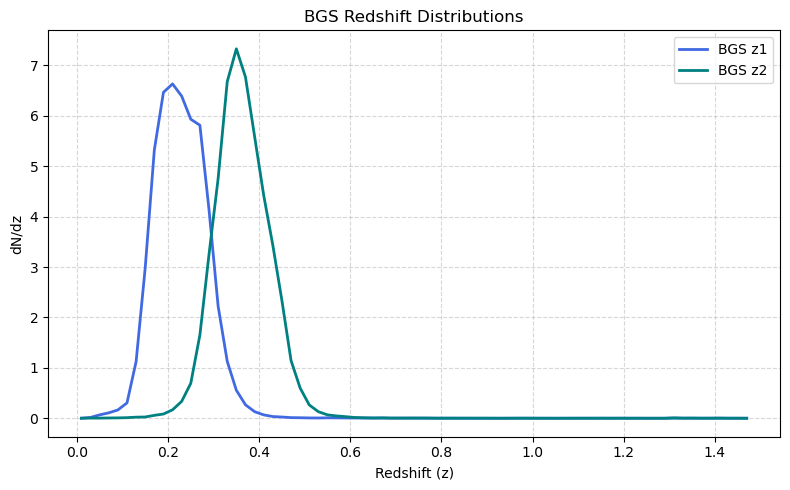

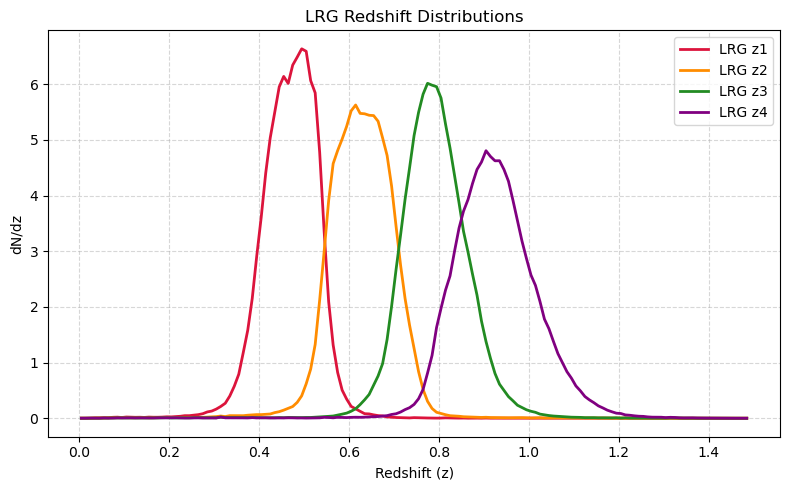

In [5]:
#### CHECK

# BGS and LRG data

# make arrays
data_dir = "data/dNdz"

bgs1 = np.loadtxt(os.path.join(data_dir, "BGSz1_dNdz.txt"))
bgs2 = np.loadtxt(os.path.join(data_dir, "BGSz2_dNdz.txt"))
BGS_distributions = np.column_stack((bgs1[:, 0], bgs1[:, 1], bgs2[:, 1]))

lrg1 = np.loadtxt(os.path.join(data_dir, "LRGz1_dNdz.txt"))
lrg2 = np.loadtxt(os.path.join(data_dir, "LRGz2_dNdz.txt"))
lrg3 = np.loadtxt(os.path.join(data_dir, "LRGz3_dNdz.txt"))
lrg4 = np.loadtxt(os.path.join(data_dir, "LRGz4_dNdz.txt"))
LRG_distributions = np.column_stack(
    (lrg1[:, 0], lrg1[:, 1], lrg2[:, 1], lrg3[:, 1], lrg4[:, 1])
)

# normalize
z_bgs = BGS_distributions[:, 0]

for i in range(1, BGS_distributions.shape[1]):
    area = np.trapezoid(BGS_distributions[:, i], x=z_bgs)
    if area > 0:
        BGS_distributions[:, i] /= area

z_lrg = LRG_distributions[:, 0]

for i in range(1, LRG_distributions.shape[1]):
    area = np.trapezoid(LRG_distributions[:, i], x=z_lrg)
    if area > 0:
        LRG_distributions[:, i] /= area

# plot
plt.figure(figsize=(8, 5))
plt.plot(
    BGS_distributions[:, 0],
    BGS_distributions[:, 1],
    label="BGS z1",
    color="royalblue",
    lw=2,
)
plt.plot(
    BGS_distributions[:, 0],
    BGS_distributions[:, 2],
    label="BGS z2",
    color="teal",
    lw=2,
)

plt.xlabel("Redshift (z)")
plt.ylabel("dN/dz")
plt.title("BGS Redshift Distributions")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
lrg_colors = ["crimson", "darkorange", "forestgreen", "purple"]

for i in range(1, 5):
    plt.plot(
        LRG_distributions[:, 0],
        LRG_distributions[:, i],
        label=f"LRG z{i}",
        color=lrg_colors[i - 1],
        lw=2,
    )

plt.xlabel("Redshift (z)")
plt.ylabel("dN/dz")
plt.title("LRG Redshift Distributions")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

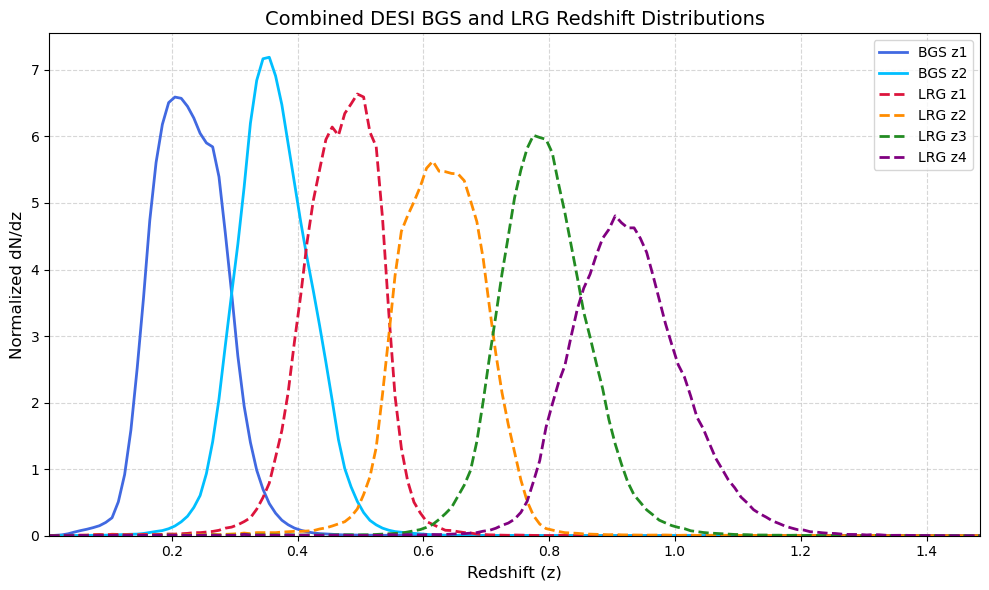

In [7]:
#### CHECK

# 1. Define a common redshift grid spanning from min to max across all data
z_min = min(BGS_distributions[:, 0].min(), LRG_distributions[:, 0].min())
z_max = max(BGS_distributions[:, 0].max(), LRG_distributions[:, 0].max())

# Use a fine step size (e.g., dz = 0.01) matching or exceeding your original grid resolution
z_master = np.arange(z_min, z_max + 0.001, 0.01)

# 2. Initialize empty array for all 6 distributions (2 BGS + 4 LRG)
# Columns: [z, BGS1, BGS2, LRG1, LRG2, LRG3, LRG4]
BGS_LRG_distributions = np.zeros((len(z_master), 7))
BGS_LRG_distributions[:, 0] = z_master

# 3. Interpolate BGS onto master grid (fill 0 outside its range)
z_bgs = BGS_distributions[:, 0]
for i in range(1, 3):  # Columns 1, 2
    BGS_LRG_distributions[:, i] = np.interp(
        z_master, z_bgs, BGS_distributions[:, i], left=0.0, right=0.0
    )

# 4. Interpolate LRG onto master grid (fill 0 outside its range)
z_lrg = LRG_distributions[:, 0]
for i in range(1, 5):  # Columns 1, 2, 3, 4
    BGS_LRG_distributions[:, i + 2] = np.interp(
        z_master, z_lrg, LRG_distributions[:, i], left=0.0, right=0.0
    )

# Re-normalize each column on the new master redshift grid
for col in range(1, 7):
    area = np.trapezoid(BGS_LRG_distributions[:, col], x=z_master)
    if area > 0:
        BGS_LRG_distributions[:, col] /= area

# plot
import matplotlib.pyplot as plt

# Extract redshift grid
z = BGS_LRG_distributions[:, 0]

# Initialize figure
plt.figure(figsize=(10, 6))

# --- Plot BGS Tracers ---
plt.plot(
    z,
    BGS_LRG_distributions[:, 1],
    label="BGS z1",
    color="royalblue",
    lw=2,
    linestyle="-",
)
plt.plot(
    z,
    BGS_LRG_distributions[:, 2],
    label="BGS z2",
    color="deepskyblue",
    lw=2,
    linestyle="-",
)

lrg_colors = ["crimson", "darkorange", "forestgreen", "purple"]
for i in range(1, 5):
    plt.plot(
        z,
        BGS_LRG_distributions[:, i + 2],  # LRG columns are index 3, 4, 5, 6
        label=f"LRG z{i}",
        color=lrg_colors[i - 1],
        lw=2,
        linestyle="--",
    )

plt.xlabel("Redshift (z)", fontsize=12)
plt.ylabel("Normalized dN/dz", fontsize=12)
plt.title("Combined DESI BGS and LRG Redshift Distributions", fontsize=14)
plt.xlim(z.min(), z.max())
plt.ylim(bottom=0)
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(fontsize=10, loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [10]:
# HSC and DES source data

# HSC
HSC_dist_0_3 = np.load("data/distributions_0.3_3_vF.npz")
print(f"Keys in distributions_0.3_3_vF.npz: {HSC_dist_0_3.files}")

HSC_dist_1_5 = np.load("data/distributions_1_5_vF.npz")
print(f"Keys in distributions_1_5_vF.npz: {HSC_dist_1_5.files}")

HSC_dist_0_3_a = np.load("data/distributions_0.3_3_vF.npz")['1/nz_mean']
HSC_dist_0_3_b = np.load("data/distributions_0.3_3_vF.npz")['2/nz_mean']
HSC_dist_0_3_c = np.load("data/distributions_0.3_3_vF.npz")['3/nz_mean']
HSC_dist_0_3_d = np.load("data/distributions_0.3_3_vF.npz")['4/nz_mean']
HSC_dist_0_3_z = np.load("data/distributions_0.3_3_vF.npz")['z']
HSC_dist_0_3 = np.column_stack((HSC_dist_0_3_z, HSC_dist_0_3_a, HSC_dist_0_3_b, HSC_dist_0_3_c, HSC_dist_0_3_d)) # make into 2D array for easy processing

HSC_dist_1_5_a = np.load("data/distributions_1_5_vF.npz")['1/nz_mean']
HSC_dist_1_5_b = np.load("data/distributions_1_5_vF.npz")['2/nz_mean']
HSC_dist_1_5_c = np.load("data/distributions_1_5_vF.npz")['3/nz_mean']
HSC_dist_1_5_d = np.load("data/distributions_1_5_vF.npz")['4/nz_mean']
HSC_dist_1_5_z = np.load("data/distributions_1_5_vF.npz")['z']
HSC_dist_1_5 = np.column_stack((HSC_dist_1_5_z, HSC_dist_1_5_a, HSC_dist_1_5_b, HSC_dist_1_5_c, HSC_dist_1_5_d)) # make into 2D array for easy processing

# DES Source Data

DES_source_data = np.loadtxt("data/des_nz_gamma.txt")

DES_source_data = DES_source_data[7:]  # removes the first 7 values (headers)
DES_source_data = DES_source_data.reshape(-1, 6) #shape into array with columns z, nz0 -- nz4

# Split into separate arrays
DES_source_z    = DES_source_data[:, 0]
DES_source_nz_a = DES_source_data[:, 1]
DES_source_nz_b = DES_source_data[:, 2]
DES_source_nz_c = DES_source_data[:, 3]
DES_source_nz_d = DES_source_data[:, 4]
#DES_source_nz_e = DES_source_data[:, 5]

DES_source_data = np.column_stack((DES_source_z, DES_source_nz_a, DES_source_nz_b, DES_source_nz_c, DES_source_nz_d))

Keys in distributions_0.3_3_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_upper', '4/nz_median_mu', '4/nz_mean_mu', '4/nz_lower_mu', '4/nz_upper_mu']
Keys in distributions_1_5_vF.npz: ['z', '1/nz_median', '1/nz_mean', '1/nz_lower', '1/nz_upper', '1/nz_median_mu', '1/nz_mean_mu', '1/nz_lower_mu', '1/nz_upper_mu', '2/nz_median', '2/nz_mean', '2/nz_lower', '2/nz_upper', '2/nz_median_mu', '2/nz_mean_mu', '2/nz_lower_mu', '2/nz_upper_mu', '3/nz_median', '3/nz_mean', '3/nz_lower', '3/nz_upper', '3/nz_median_mu', '3/nz_mean_mu', '3/nz_lower_mu', '3/nz_upper_mu', '4/nz_median', '4/nz_mean', '4/nz_lower', '4/nz_up

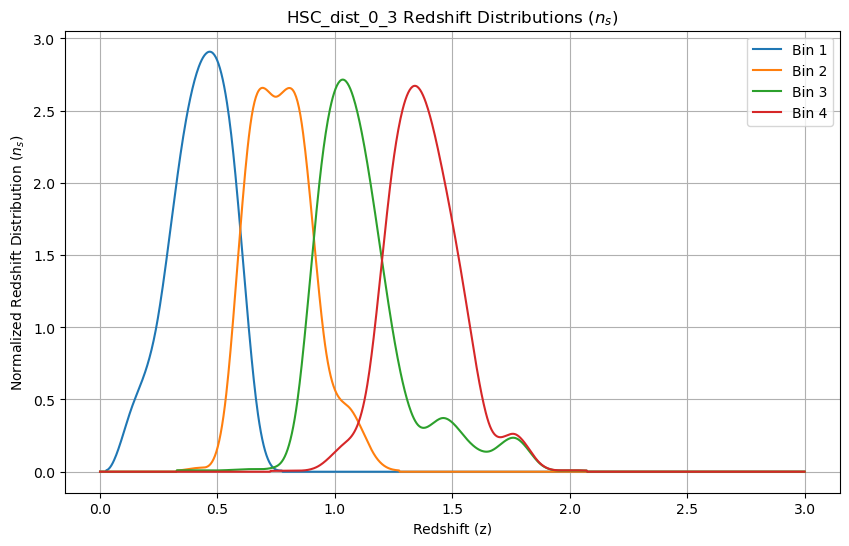

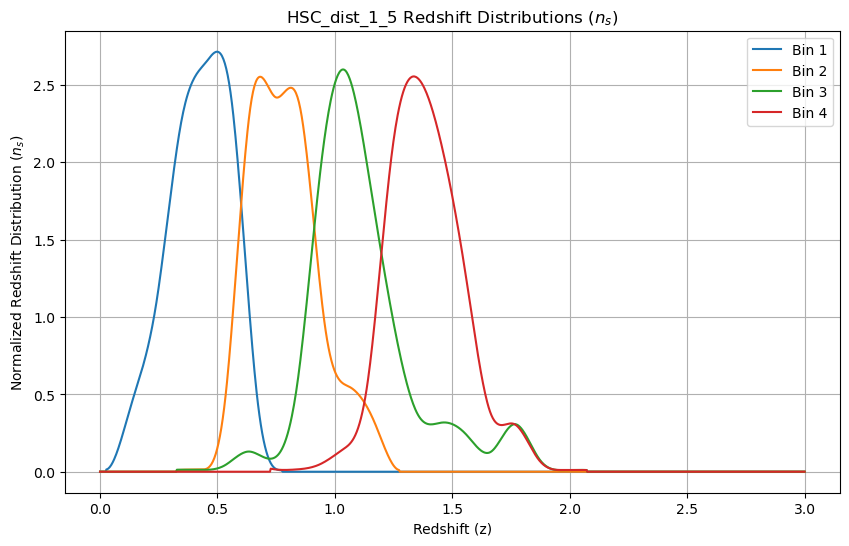

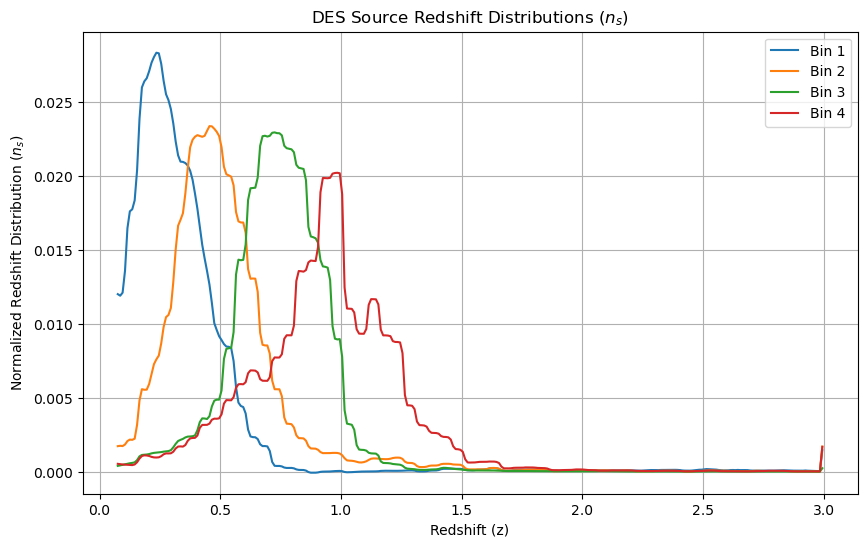

In [11]:
# graph HSC and DES source distributions

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_a, label='Bin 1')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_b, label='Bin 2')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_c, label='Bin 3')
plt.plot(HSC_dist_0_3_z, HSC_dist_0_3_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_0_3 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_a, label='Bin 1')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_b, label='Bin 2')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_c, label='Bin 3')
plt.plot(HSC_dist_1_5_z, HSC_dist_1_5_d, label='Bin 4')
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('HSC_dist_1_5 Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(DES_source_z, DES_source_nz_a, label='Bin 1')
plt.plot(DES_source_z, DES_source_nz_b, label='Bin 2')
plt.plot(DES_source_z, DES_source_nz_c, label='Bin 3')
plt.plot(DES_source_z, DES_source_nz_d, label='Bin 4')
#### nz_5 has values all of order e7 or above,
#### while the others have values of order e-5 or below
#### what's going on here?
plt.xlabel('Redshift (z)')
plt.ylabel('Normalized Redshift Distribution ($n_s$)')
plt.title('DES Source Redshift Distributions ($n_s$)')
plt.legend()
plt.grid(True)
plt.show()

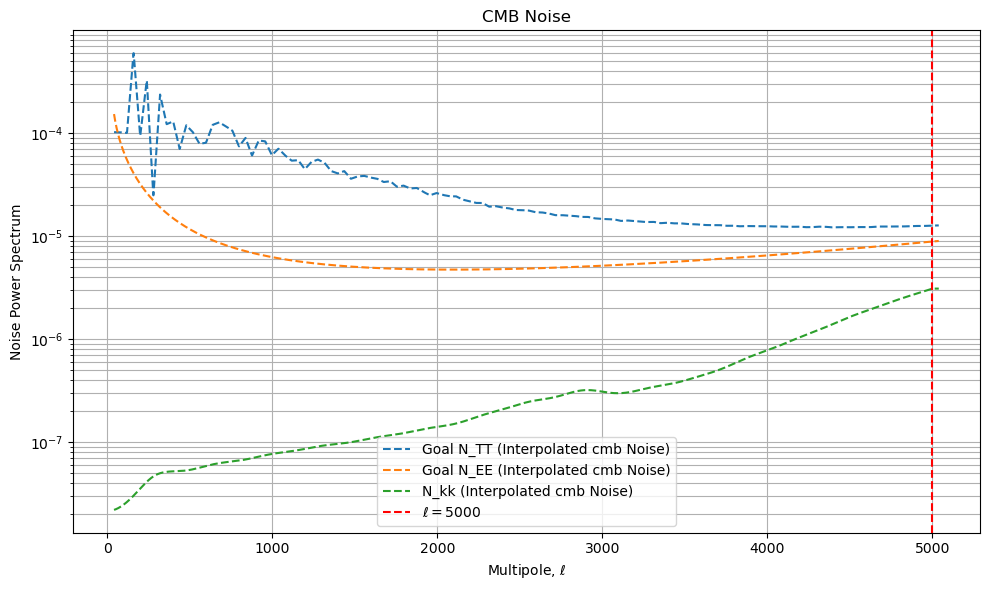

In [21]:
# build noise magnification
# BGS shot noise ref: https://arxiv.org/pdf/2407.04607
# LRG shot noise ref:
# DES noise ref: https://arxiv.org/html/2511.04681v2
# HSC noise ref: https://arxiv.org/pdf/2507.01386
# SO noise ref:
# magnification ref: https://arxiv.org/pdf/2503.24385

sigma = 0.26
LRG_n_bar_deg2 = np.array([81.9, 148.1, 162.4, 148.3]) # Galaxies per square degree
LRG_n_bar_steradian = LRG_n_bar_deg2 * (180.0 / np.pi)**2
HSC_n_bar_arcmin2 = np.array([3.77, 5.07, 4.00, 2.12])
HSC_n_bar_deg2 = HSC_n_bar_arcmin2 * (60 ** 2)
HSC_n_bar_steradian = HSC_n_bar_deg2 * (180.0 / np.pi)**2
DES_n_bar_arcmin2 = np.array([5.59, 5.59, 5.59, 5.59])
DES_n_bar_deg2 = DES_n_bar_arcmin2 * (60 ** 2)
DES_n_bar_steradian = DES_n_bar_deg2 * (180.0 / np.pi)**2
BGS_shot_noise = [4.63e-7, 9.18e-7]
BGS_LRG_shot_noise = [4.63e-7, 9.18e-7] # copy BGS_shot noise and then start appending values
LRG_shot_noise = np.zeros_like(LRG_n_bar_steradian)

for i in range(len(LRG_shot_noise)):
    LRG_shot_noise[i] = 1 / LRG_n_bar_steradian[i]
    BGS_LRG_shot_noise.append(LRG_shot_noise[i])
LRG_shot_noise = np.array(LRG_shot_noise)
BGS_LRG_shot_noise = np.array(BGS_LRG_shot_noise)

HSC_shape_noise = np.zeros_like(HSC_n_bar_steradian)
for i in range(len(HSC_shape_noise)):
    HSC_shape_noise[i] = sigma ** 2 / HSC_n_bar_steradian[i]

DES_shape_noise = np.zeros_like(DES_n_bar_steradian)
for i in range(len(DES_shape_noise)):
    DES_shape_noise[i] = sigma ** 2 / DES_n_bar_steradian[i]

# cmb noise arises from idk a bunch of stuff
# we have an SO noise curve, but it does not have precisely the same ells as our C_l
# we must interpolate the N_kk to produce a useful noise curve
SO_goal_T_noise_data = np.loadtxt("data/SO_LAT_Nell_T_atmv1_goal_fsky0p4_ILC_CMB.txt")
SO_goal_T_noise_ells = SO_goal_T_noise_data[:, 0]
SO_goal_N_TT = SO_goal_T_noise_data[:, 1]
SO_goal_E_noise_data = np.loadtxt("data/SO_LAT_Nell_P_goal_fsky0p4_ILC_CMB_E.txt")
SO_goal_E_noise_ells = SO_goal_E_noise_data[:, 0]
SO_goal_N_EE = SO_goal_E_noise_data[:, 1]
SO_kk_noise_data = np.genfromtxt("data/nlkk_v3_1_0deproj0_SENS2_fsky0p4_it_lT30-3000_lP30-5000.dat")
SO_kk_noise_ells = SO_kk_noise_data[:, 0]
SO_N_kk = SO_kk_noise_data[:, 7]
ells_for_noise_interp = np.arange(40, 5000 + 40)

# Use fill_value=(N_kk[0], N_kk[-1]) to cap the noise at the boundaries
interpolated_goal_N_TT_func = interp1d(SO_goal_T_noise_ells, SO_goal_N_TT, bounds_error=False, fill_value=(SO_goal_N_TT[0], SO_goal_N_TT[-1]))
SO_goal_cmb_noise_TT = interpolated_goal_N_TT_func(ells_for_noise_interp)
interpolated_goal_N_EE_func = interp1d(SO_goal_E_noise_ells, SO_goal_N_EE, bounds_error=False, fill_value=(SO_goal_N_EE[0], SO_goal_N_EE[-1]))
SO_goal_cmb_noise_EE = interpolated_goal_N_EE_func(ells_for_noise_interp)
interpolated_N_kk_func = interp1d(SO_kk_noise_ells, SO_N_kk, bounds_error=False, fill_value=(SO_N_kk[0], SO_N_kk[-1]))
SO_cmb_noise_kk = interpolated_N_kk_func(ells_for_noise_interp)

# plot cmb noise to see what it looks like
plt.figure(figsize=(10, 6))
plt.semilogy(ells_for_noise_interp, SO_goal_cmb_noise_TT, label='Goal N_TT (Interpolated cmb Noise)', linestyle='--')
plt.semilogy(ells_for_noise_interp, SO_goal_cmb_noise_EE, label='Goal N_EE (Interpolated cmb Noise)', linestyle='--')
plt.semilogy(ells_for_noise_interp, SO_cmb_noise_kk, label='N_kk (Interpolated cmb Noise)', linestyle='--')
plt.xlabel('Multipole, $\ell$')
plt.ylabel('Noise Power Spectrum')
plt.title('CMB Noise')
plt.axvline(x=5000, color='red', linestyle='--', label='$\ell = 5000$') # Added vertical line
plt.legend()
plt.grid(True, which="both", ls="-")
plt.tight_layout()
plt.show()

# Convariance Matrices

The covariance matrix is rather complicated because we have many different types of data for which we need to consider the covariances. Though we will generally only consider lensing ratios (and perhaps primaries), we'll set up the full data vector:

$$\mathbf{D} = [C_\ell^{\kappa_{c}\kappa_{c}}, C_\ell^{\kappa_{c}g}, C_\ell^{\kappa_{c}\kappa_{g}}, C_\ell^{\kappa_{g}\kappa_{g}}, C_\ell^{\kappa_{g}g}, C_\ell^{gg}, C_\ell^{TT}, C_\ell^{EE}]$$

This vector consists of:
* **cmb lensing convergence power spectrum:** $C_\ell^{\kappa_{c}\kappa_{c}}$
* **Galaxy lensing–cmb lensing cross-spectrum:** $C_\ell^{\kappa_{c}\kappa_{g}}$ (cmb lensing - galaxy lensing)
* **Lens galaxies–cmb lensing cross-spectrum:** $C_\ell^{\kappa_{c}g}$ (cmb lensing - galaxy number density)
* **Galaxy lensing convergence auto/cross-spectrum:** $C_\ell^{\kappa_{g}\kappa_{g}}$
* **Lens galaxy-galaxy lensing cross-spectrum:** $C_\ell^{g\kappa_{g}}$ (galaxy - galaxy lensing)
* **Lens galaxies auto/cross-spectrum:** $C_\ell^{gg}$ (galaxy clustering)
* **CMB temperature and polarization spectra:** $C_\ell^{TT}$, $C_\ell^{EE}$
  
Note: In all the code written and used before 06/26/2026 $\kappa_{c}$ is written as $\phi$, $\kappa_{c}$ is listed as $l$, and $g$ is listed as $g$. I originally expected to be working with lensing potential, and changing the labels generated some bugs, so I left it as it was for a while.

We consider Gaussian covariances
$$\text{Cov}_{\text{master }}[i,j] = \text{Cov}(D_i, D_j)$$
$$\mathrm{Cov}(C^{ab}_{\ell}, C^{cd}_{\ell'}) = \frac{\delta_{\ell \ell'}}{(2\ell + 1)\, f_{\mathrm{sky}}} \left( C^{ac}_\ell C^{bd}_\ell + C^{ad}_\ell C^{bc}_\ell \right)$$

In order to do a proper MCMC, we will need to calculate the entries in the master covariance matrix and input it into Cobaya.

Note that calculating covariances will be a little tricky because we'll need the computer to figure out what spectra are being considered, separate out their variables, swap them around, and then locate the correct spectra for the product terms.

In [ ]:
# calculate and save flat LCDM fiducial data vector and covariance matrix for single bin w/lensing ratios primaries

# ensure output directory exists
os.makedirs('cobaya_data', exist_ok=True)

print("Calculating fiducial data vector and covariance matrix for single bin w/primaries...")

# extract other parameters directly, or hardcode them if they are constant for this generation step
f_sky = 0.4
l_min = 40
n_ell = 5000
binsize = 50
magnification_bias_lenses = 0.8

# build covariance and spectra dictionary w/o emulator, so they'll be maximally accurate
cov_obj, fiducial_spectra_dict, f_map = \
    build_covariance_from_data(
        flat_LCDM_cosmology,
        BGS_LRG_distribution,
        HSC_dist_0_3,
        f_sky=f_sky,
        l_min=l_min,
        n_ell=n_ell,
        binsize=binsize,
        shot_noise_lens=BGS_shot_noise,
        shape_noise_source=HSC_shape_noise,
        cmb_noise_kk=SO_cmb_noise_kk,
        cmb_noise_TT=SO_goal_cmb_noise_TT,
        cmb_noise_EE=SO_goal_cmb_noise_EE,
        magnification_bias_lenses=magnification_bias_lenses,
        desired_spectra=['CG', 'GL', 'EE', 'TT', 'TE'],
        linear_emulator=None,
        boost_emulator=None,
        cmb_primaries = True,
        z_max = 6,
        n_chi = 1024
    )

# get the covariance matrix
covariance_matrix = cov_obj.matrix

# extract and flatten the fiducial data vector
observed_data_vector = build_data_vector(forecast_map = f_map, spectra_dict = fiducial_spectra_dict, n_ell = n_ell, binsize = binsize)

# Save to files
data_vector_filename = 'cobaya_data/flat_LCDM_LRP_Photo_HSC_est_BGS_data_vector.npy'
covariance_filename = 'cobaya_data/flat_LCDM_LRP_Photo_HSC_est_BGS_covariance_matrix.npy'

np.save(data_vector_filename, observed_data_vector)
np.save(covariance_filename, covariance_matrix)

# Fishers

## DESI DR2 Comp

### Summary

In [9]:
# results without priors

data_dict = {
    "ΛCDM": [
        ["SO + DESI BGS + DESY3 (Lensing Ratios)", "< 0.317", "0.68 \\pm 0.53", "—", "—", "—"],
        ["SO (Primaries)", "0.3027 \\pm 0.0042", "0.6817 \\pm 0.0031", "—", "—", "—"],
        ["SO + DESI BGS + DESY3 (Primaries + Lensing Ratios)", "0.3027 \\pm 0.0014", "0.6817 \\pm 0.0011", "—", "—", "—"],
        ["DESI BAO + CMB (DESI DR2)", "0.3027 \\pm 0.0036", "0.6817 \\pm 0.0028", "—", "—", "—"],
    ],
    "ΛCDM + Ω_K": [
        ["SO + DESI BGS + DESY3 (Lensing Ratios)", "< 0.318", "0.68 \\pm 0.59", "0.002 \\pm 0.066", "—", "—"],
        ["SO (Primaries)", "0.3034 \\pm 0.0091", "0.685 \\pm 0.012", "0.0023 \\pm 0.0030", "—", "—"],
        ["SO + DESI BGS + DESY3 (Primaries + Lensing Ratios)", "0.3034 \\pm 0.0063", "0.6850 \\pm 0.0091", "0.0023 \\pm 0.0025", "—", "—"],
        ["DESI BAO + CMB (DESI DR2)", "0.3034 \\pm 0.0037", "0.6850 \\pm 0.0033", "0.0023 \\pm 0.0011", "—", "—"],
    ],
    "wCDM": [
        ["SO + DESI BGS + DESY3 (Lensing Ratios)", "< 0.329", "0.67 \\pm 0.68", "—", "-0.97 \\pm 0.16", "—"],
        ["SO (Primaries)", "0.3098 \\pm 0.0023", "0.6734 \\pm 0.0028", "—", "-0.971 \\pm 0.015", "—"],
        ["SO + DESI BGS + DESY3 (Primaries + Lensing Ratios)", "0.3098 \\pm 0.0023", "0.6734 \\pm 0.0024", "—", "-0.9706 \\pm 0.0082", "—"],
        ["DESI BAO + CMB (DESI DR2)", "0.2927 \\pm 0.0073", "0.6951 \\pm 0.0092", "—", "-1.055 \\pm 0.036", "—"],
        ["DESI BAO + CMB + DESY5 SNe (DESI DR2)", "0.3098 \\pm 0.0050", "0.6734 \\pm 0.0054", "—", "-0.971 \\pm 0.021", "—"],
    ],
    "w_0w_aCDM": [
        ["SO + DESI BGS + DESY3 (Lensing Ratios)", "< 0.337", "0.67 \\pm 0.58", "—", "-0.75 \\pm 0.30", "-0.9 \\pm 1.4"],
        ["SO (Primaries)", "0.3189 \\pm 0.0067", "0.6674 \\pm 0.0070", "—", "-0.752 \\pm 0.073", "-0.86 \\pm 0.31"],
        ["SO + DESI BGS + DESY3 (Primaries + Lensing Ratios)", "0.3190 \\pm 0.0057", "0.6674 \\pm 0.0057", "—", "-0.752 \\pm 0.054", "-0.86 \\pm 0.19"],
        ["DESI BAO + CMB (DESI DR2)", "0.353 \\pm 0.021", "0.636^{+0.016}_{-0.021}", "—", "-0.42 \\pm 0.21", "-1.75 \\pm 0.58"],
        ["DESI BAO + CMB + DESY5 SNe (DESI DR2)", "0.3191 \\pm 0.0056", "0.6674 \\pm 0.0056", "—", "-0.752 \\pm 0.057", "-0.86^{+0.23}_{-0.20}"],
    ],
    "w_0w_aCDM + Ω_K": [
        ["SO + DESI BGS + DESY3 (Lensing Ratios)", "< 0.337", "0.67 \\pm 0.54", "0.001 \\pm 0.088", "-0.76 \\pm 0.31", "-0.8 \\pm 1.7"],
        ["SO (Primaries)", "< 0.391", "0.67 \\pm 0.16", "0.0008 \\pm 0.0072", "-0.8 \\pm 1.5", "-0.8 \\pm 4.0"],
        ["SO + DESI BGS + DESY3 (Primaries + Lensing Ratios)", "0.319 \\pm 0.013", "0.668 \\pm 0.013", "0.0008 \\pm 0.0019", "-0.762 \\pm 0.092", "-0.81 \\pm 0.26"],
        ["DESI BAO + CMB + DESY5 SNe (DESI DR2)", "0.3193 \\pm 0.0056", "0.6682 \\pm 0.0058", "0.0008 \\pm 0.0013", "-0.762 \\pm 0.060", "-0.81 \\pm 0.24"],
    ]
}

# Mapping string keys to beautifully formatted bold LaTeX headers
latex_header_map = {
    "ΛCDM": r"**$\Lambda\text{CDM}$**",
    "ΛCDM + Ω_K": r"**$\Lambda\text{CDM} + \Omega_K$**",
    "wCDM": r"**$w\text{CDM}$**",
    "w_0w_aCDM": r"**$w_0w_a\text{CDM}$**",
    "w_0w_aCDM + Ω_K": r"**$w_0w_a\text{CDM} + \Omega_K$**"
}

# 2. Reconstruct the rows using dynamic inline Markdown formulas
table_rows = []
for model, rows in data_dict.items():
    pretty_header = latex_header_map.get(model, f"**{model}**")
    table_rows.append([pretty_header, "", "", "", "", ""])
    
    for row in rows:
        formatted_row = [f"&nbsp;&nbsp;&nbsp;&nbsp;{row[0]}"]  
        
        for cell in row[1:]:
            if cell != "—" and not cell.startswith("<"):
                formatted_row.append(f"${cell}$")
            elif cell.startswith("<"):
                limit_val = cell.split("<")[-1].strip()
                formatted_row.append(f"$< {limit_val}$")
            else:
                formatted_row.append(cell)
                
        table_rows.append(formatted_row)

# 3. Headers using standard LaTeX math-mode layouts
headers = [
    "Model/Dataset", 
    "$\\Omega_m$", 
    "$h$", 
    "$\\Omega_K$", 
    "$w\\text{ or }w_0$", 
    "$w_a$"
]

# 4. Generate and display the native Markdown structure
md_lines = [
    "### OUTDATED Forecasted Cosmological Parameter Constraints (Priorless Fisher, Binsize = 20)",
    "",
    f"| {' | '.join(headers)} |",
    f"| :--- | {' | '.join([':---:'] * (len(headers) - 1))} |"
]

for row in table_rows:
    if row[1] == "" and row[2] == "":
        md_lines.append(f"| {row[0]} | | | | | |")
    else:
        md_lines.append(f"| {' | '.join(row)} |")

# Create a text footnote block wrapped in a width-constrained HTML container
footnote_html = """
<div style="max-width: 900px; width: 100%; font-size: 14px; color: #555; line-height: 1.5; margin-top: 12px; padding-left: 4px; text-align: justify;">
<strong>Note:</strong> SO and SO×DESI constraints shown are from Fisher forecasts. BAO constraints shown are from DESI DR2. Fiducial cosmologies were built using
central values from DESI BAO + CMB (or, when available, DESI BAO + CMB + DESY5) chains. CMB primaries and secondaries were taken from projected
SO data, lens galaxies from DESI photometric BGS bins, and source galaxies from DESY3 bins. Data were binned into groups of 20 to decrease the run
time. Constraints from primaries or primaries and lensing ratios stayed the same or decreased by a few percent when bin size was cut in half. Constraints
from lensing ratios alone were roughly proportional to the square root of the bin size. We will aim to better understand the physics underlying this
relationship in the future. For more details, see the 'Binsize Tests' file.
</div>
"""

# Display both the generated Markdown table and the constrained footnote seamlessly
display(Markdown("\n".join(md_lines)), HTML(footnote_html))

### Forecasted Cosmological Parameter Constraints (Priorless Fisher, Binsize = 20)

| Model/Dataset | $\Omega_m$ | $h$ | $\Omega_K$ | $w\text{ or }w_0$ | $w_a$ |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **$\Lambda\text{CDM}$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Lensing Ratios) | $< 0.317$ | $0.68 \pm 0.53$ | — | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primaries) | $0.3027 \pm 0.0042$ | $0.6817 \pm 0.0031$ | — | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Primaries + Lensing Ratios) | $0.3027 \pm 0.0014$ | $0.6817 \pm 0.0011$ | — | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB (DESI DR2) | $0.3027 \pm 0.0036$ | $0.6817 \pm 0.0028$ | — | — | — |
| **$\Lambda\text{CDM} + \Omega_K$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Lensing Ratios) | $< 0.318$ | $0.68 \pm 0.59$ | $0.002 \pm 0.066$ | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primaries) | $0.3034 \pm 0.0091$ | $0.685 \pm 0.012$ | $0.0023 \pm 0.0030$ | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Primaries + Lensing Ratios) | $0.3034 \pm 0.0063$ | $0.6850 \pm 0.0091$ | $0.0023 \pm 0.0025$ | — | — |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB (DESI DR2) | $0.3034 \pm 0.0037$ | $0.6850 \pm 0.0033$ | $0.0023 \pm 0.0011$ | — | — |
| **$w\text{CDM}$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Lensing Ratios) | $< 0.329$ | $0.67 \pm 0.68$ | — | $-0.97 \pm 0.16$ | — |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primaries) | $0.3098 \pm 0.0023$ | $0.6734 \pm 0.0028$ | — | $-0.971 \pm 0.015$ | — |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Primaries + Lensing Ratios) | $0.3098 \pm 0.0023$ | $0.6734 \pm 0.0024$ | — | $-0.9706 \pm 0.0082$ | — |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB (DESI DR2) | $0.2927 \pm 0.0073$ | $0.6951 \pm 0.0092$ | — | $-1.055 \pm 0.036$ | — |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB + DESY5 SNe (DESI DR2) | $0.3098 \pm 0.0050$ | $0.6734 \pm 0.0054$ | — | $-0.971 \pm 0.021$ | — |
| **$w_0w_a\text{CDM}$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Lensing Ratios) | $< 0.337$ | $0.67 \pm 0.58$ | — | $-0.75 \pm 0.30$ | $-0.9 \pm 1.4$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primaries) | $0.3189 \pm 0.0067$ | $0.6674 \pm 0.0070$ | — | $-0.752 \pm 0.073$ | $-0.86 \pm 0.31$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Primaries + Lensing Ratios) | $0.3190 \pm 0.0057$ | $0.6674 \pm 0.0057$ | — | $-0.752 \pm 0.054$ | $-0.86 \pm 0.19$ |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB (DESI DR2) | $0.353 \pm 0.021$ | $0.636^{+0.016}_{-0.021}$ | — | $-0.42 \pm 0.21$ | $-1.75 \pm 0.58$ |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB + DESY5 SNe (DESI DR2) | $0.3191 \pm 0.0056$ | $0.6674 \pm 0.0056$ | — | $-0.752 \pm 0.057$ | $-0.86^{+0.23}_{-0.20}$ |
| **$w_0w_a\text{CDM} + \Omega_K$** | | | | | |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Lensing Ratios) | $< 0.337$ | $0.67 \pm 0.54$ | $0.001 \pm 0.088$ | $-0.76 \pm 0.31$ | $-0.8 \pm 1.7$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO (Primaries) | $< 0.391$ | $0.67 \pm 0.16$ | $0.0008 \pm 0.0072$ | $-0.8 \pm 1.5$ | $-0.8 \pm 4.0$ |
| &nbsp;&nbsp;&nbsp;&nbsp;SO + DESI BGS + DESY3 (Primaries + Lensing Ratios) | $0.319 \pm 0.013$ | $0.668 \pm 0.013$ | $0.0008 \pm 0.0019$ | $-0.762 \pm 0.092$ | $-0.81 \pm 0.26$ |
| &nbsp;&nbsp;&nbsp;&nbsp;DESI BAO + CMB + DESY5 SNe (DESI DR2) | $0.3193 \pm 0.0056$ | $0.6682 \pm 0.0058$ | $0.0008 \pm 0.0013$ | $-0.762 \pm 0.060$ | $-0.81 \pm 0.24$ |

Loading BAO+CMB+Pantheon+ (DESI DR2)...
Loading BAO+CMB+Union3 (DESI DR2)...
Loading BAO+CMB+DESY5 (DESI DR2)...
Loading BAO+CMB (DESI DR2)...
Matrix shape: (7, 7)


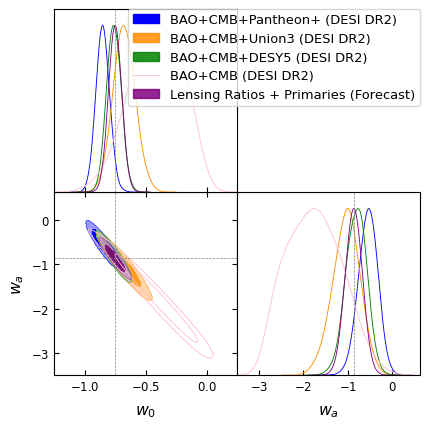

In [4]:
# ==========================================
# 1. Load DESI DR2 Chains from NERSC
# ==========================================
DESI_DIR = "/global/cfs/cdirs/desi/public/papers/y3/bao-cosmo-params/cobaya/base_omegak_w_wa"

datasets = {
    "BAO+CMB+Pantheon+ (DESI DR2)": "desi-bao-all_pantheonplus_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "BAO+CMB+Union3 (DESI DR2)": "desi-bao-all_union3_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "BAO+CMB+DESY5 (DESI DR2)": "desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "BAO+CMB (DESI DR2)": "desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing"
}

desi_chains = []
for label, folder_name in datasets.items():
    chain_root = os.path.join(DESI_DIR, folder_name, "chain")
    print(f"Loading {label}...")
    sample = loadMCSamples(chain_root, settings={'ignore_rows': 0.3})
    
    # Alias 'w' to 'w0' in DESI chains if needed for parameter mapping
    if 'w' in [p.name for p in sample.paramNames.names] and 'w0' not in [p.name for p in sample.paramNames.names]:
        sample.paramNames.parWithName('w').name = 'w0'
        
    sample.label = label
    desi_chains.append(sample)

is_filled = [True, True, True, False, True]
line_styles = ['-', '-', '-', '-', '-',] 
# ==========================================
# 2. Load Fisher Covariance Matrices & Sample
# ==========================================
sampled_params = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']

cov_files = {
#    "SOxDESI Photometric Lensing Ratios": "Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt",
#    "SO Primaries": "Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_Primaries_Binsize=20.txt",
    "Lensing Ratios + Primaries (Forecast)": "Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_DESY3_BGS_Binsize=20.txt"
}

fisher_chains = []
for label, filepath in cov_files.items():

    # Read ignoring '#' comments, using Line 2 as column names, and NO index column
    df = pd.read_csv(filepath, sep=r'\s+', comment='#')
    
    cov_matrix = df.to_numpy()
    print("Matrix shape:", cov_matrix.shape)  # Output: (7, 7)

    chain = sample_fisher_with_uniform_priors(
        fiducial_cosmology=flat_w0waCDM_cosmology,
        sampled_params=sampled_params,
        covariance=cov_matrix,
        name_tag=label,
        uniform_priors=uniform_prior,
        num_samples=200000
    )
    chain.label = label
    fisher_chains.append(chain)


# ==========================================
# 3. Generate Combined Overlay Plot
# ==========================================
g = plot_Fisher_from_matrices(
    fiducial_cosmology=flat_w0waCDM_cosmology,
    Fisher_chains=fisher_chains,
    DESI_chains=desi_chains,
    sampled_params=sampled_params,
    params_to_plot=['w0', 'wa'],
    save_plot=True,
    title="Full w0waOverlap Plot",
    filled = is_filled,
#   line_styles = line_styles,
    plot_folder="plots/Fisher Forecasts",
)

Loading BAO+CMB+DESY5 (DESI DR2)...
Matrix shape: (7, 7)


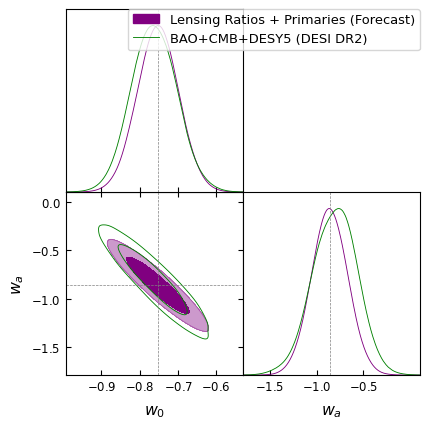

In [6]:
# ==========================================
# 1. Load DESI DR2 Chains from NERSC
# ==========================================
DESI_DIR = "/global/cfs/cdirs/desi/public/papers/y3/bao-cosmo-params/cobaya/base_omegak_w_wa"

datasets = {
#    "BAO+CMB+Pantheon+ (DESI DR2)": "desi-bao-all_pantheonplus_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
#    "BAO+CMB+Union3 (DESI DR2)": "desi-bao-all_union3_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
    "BAO+CMB+DESY5 (DESI DR2)": "desi-bao-all_desy5sn_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing",
#    "BAO+CMB (DESI DR2)": "desi-bao-all_planck2018-lowl-TT-clik_planck2018-lowl-EE-clik_planck-NPIPE-highl-CamSpec-TTTEEE_planck-act-dr6-lensing"
}

desi_chains = []
for label, folder_name in datasets.items():
    chain_root = os.path.join(DESI_DIR, folder_name, "chain")
    print(f"Loading {label}...")
    sample = loadMCSamples(chain_root, settings={'ignore_rows': 0.3})
    
    # Alias 'w' to 'w0' in DESI chains if needed for parameter mapping
    if 'w' in [p.name for p in sample.paramNames.names] and 'w0' not in [p.name for p in sample.paramNames.names]:
        sample.paramNames.parWithName('w').name = 'w0'
        
    sample.label = label
    desi_chains.append(sample)

is_filled = [True, False]
line_styles = ['-', '-', '-', '-', '-',] 
# ==========================================
# 2. Load Fisher Covariance Matrices & Sample
# ==========================================
sampled_params = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']

cov_files = {
#    "SOxDESI Photometric Lensing Ratios": "Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LR_All_Photometric_Bins_Binsize=25.txt",
#    "SO Primaries": "Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_Primaries_Binsize=20.txt",
    "Lensing Ratios + Primaries (Forecast)": "Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_DESY3_BGS_Binsize=20.txt"
}

fisher_chains = []
for label, filepath in cov_files.items():

    # Read ignoring '#' comments, using Line 2 as column names, and NO index column
    df = pd.read_csv(filepath, sep=r'\s+', comment='#')
    
    cov_matrix = df.to_numpy()
    print("Matrix shape:", cov_matrix.shape)  # Output: (7, 7)

    chain = sample_fisher_with_uniform_priors(
        fiducial_cosmology=flat_w0waCDM_cosmology,
        sampled_params=sampled_params,
        covariance=cov_matrix,
        name_tag=label,
        uniform_priors=uniform_prior,
        num_samples=200000
    )
    chain.label = label
    fisher_chains.append(chain)


# ==========================================
# 3. Generate Combined Overlay Plot
# ==========================================
g = plot_Fisher_from_matrices(
    fiducial_cosmology=flat_w0waCDM_cosmology,
    Fisher_chains=fisher_chains,
    DESI_chains=desi_chains,
    sampled_params=sampled_params,
    params_to_plot=['w0', 'wa'],
    save_plot=True,
    title="Restricted w0waOverlap Plot",
    filled = is_filled,
#   line_styles = line_styles,
    plot_folder="plots/Fisher Forecasts",
)

### DESI BGS, SO, and DESY3

#### Flat LCDM

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LR_Photo_BGS_LRG_DESY3_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LR_Photo_BGS_LRG_DESY5_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (DES, LRG, BGS) Flat LCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric Lensing Ratios (DES, LRG, BGS) Flat LCDM Fisher Forecast, Bin Size = 20 -- All Sampled Params Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_flat_lcdm_fisher_forecast_bin_size_=_20.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3027\pm 0.0042$ | $\Omega_m = 0.3027^{+0.0082}_{-0.0082}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3027\pm 0.0042$ | $\Omega_m = 0.3027^{+0.0083}_{-0.0082}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6817\pm 0.0031$ | $h = 0.6817^{+0.0061}_{-0.0060}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6817\pm 0.0031$ | $h = 0.6817^{+0.0060}_{-0.0061}$ |
| --- | --- | --- | --- |

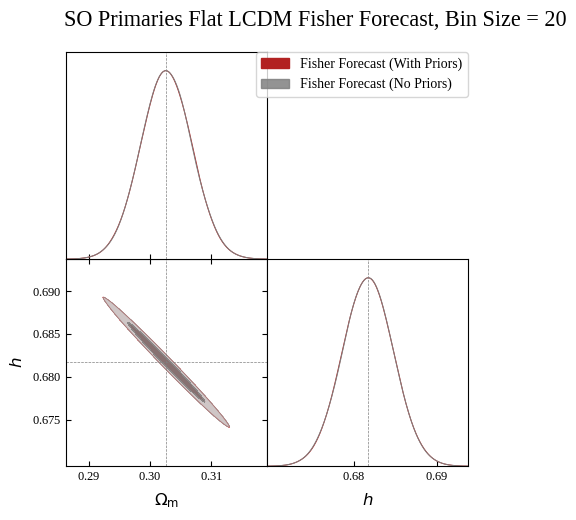

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_flat_lcdm_fisher_forecast_bin_size_=_20_--_all_sampled_parameteres_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2532\pm 0.0038$ | $\Omega_{c} = 0.2532^{+0.0075}_{-0.0075}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2532\pm 0.0038$ | $\Omega_{c} = 0.2532^{+0.0075}_{-0.0075}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04807\pm 0.00036$ | $\Omega_{b} = 0.04807^{+0.00071}_{-0.00071}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04807\pm 0.00036$ | $\Omega_{b} = 0.04807^{+0.00071}_{-0.00071}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6817\pm 0.0031$ | $h = 0.6817^{+0.0060}_{-0.0060}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6817\pm 0.0031$ | $h = 0.6817^{+0.0060}_{-0.0060}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.1220\pm 0.0050\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.1220^{+0.0098}_{-0.0099}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.1220\pm 0.0050\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.1220^{+0.0098}_{-0.0098}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9693\pm 0.0027$ | $n_s = 0.9693^{+0.0054}_{-0.0054}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9693\pm 0.0027$ | $n_s = 0.9693^{+0.0053}_{-0.0054}$ |
| --- | --- | --- | --- |

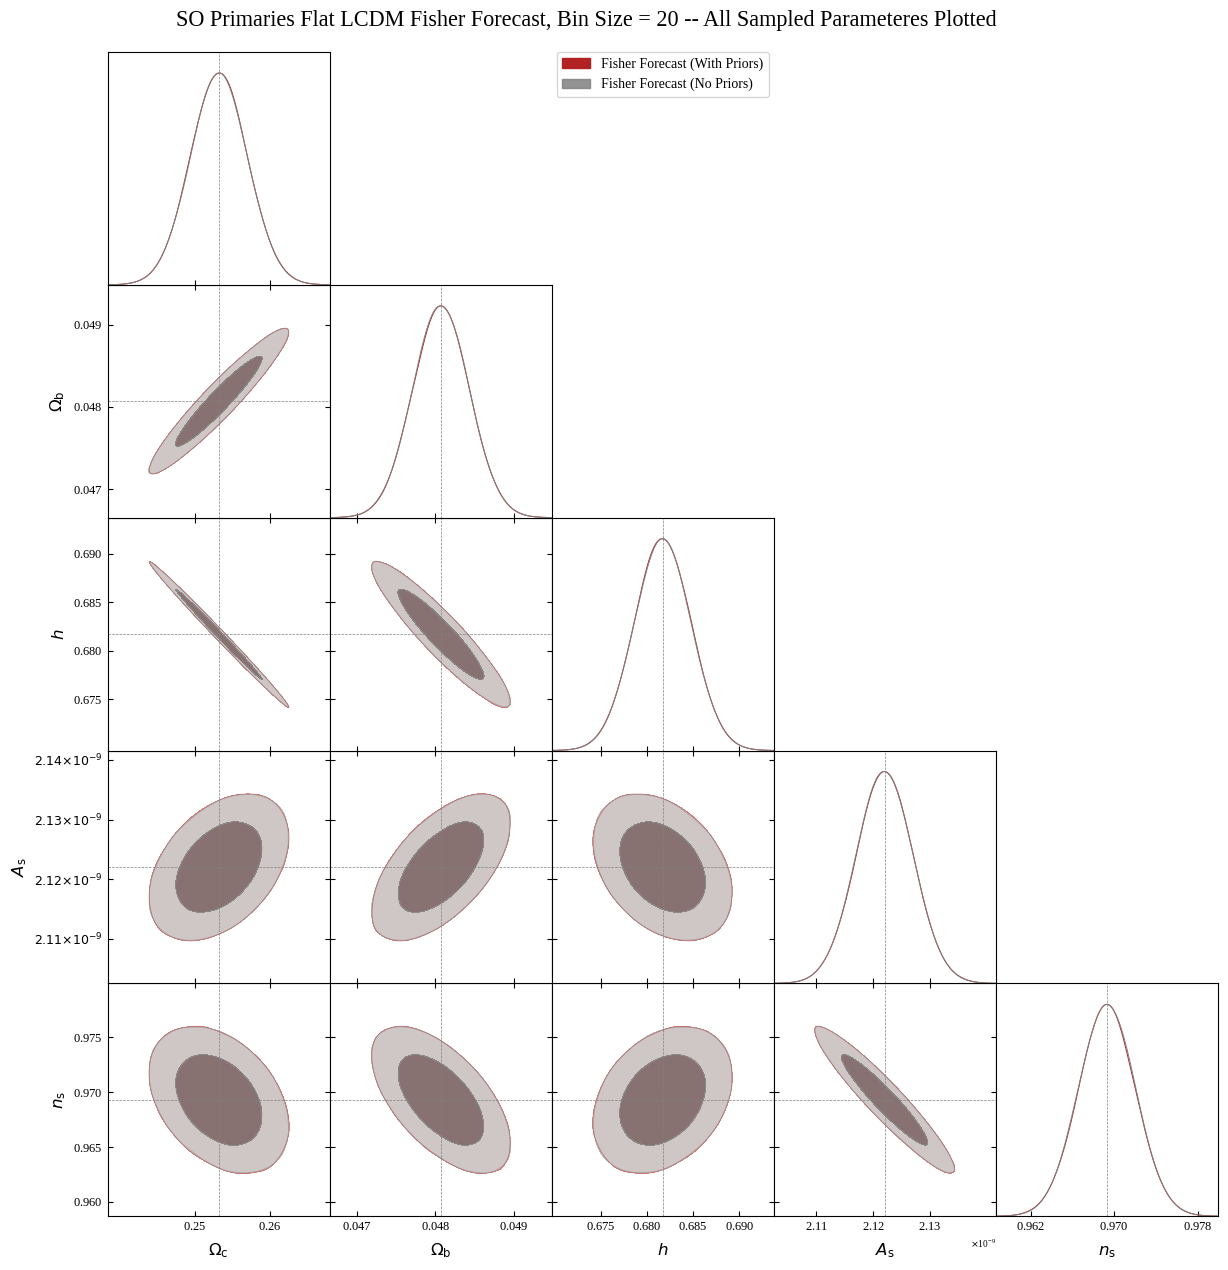

total_time:  0:03:27.327955


In [37]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=HSC_dist_0_3,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_TT+TE_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_TT+EE_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Flat LCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Flat LCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameteres Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3027\pm 0.0012$ | $\Omega_m = 0.3027^{+0.0024}_{-0.0024}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3027\pm 0.0012$ | $\Omega_m = 0.3027^{+0.0024}_{-0.0024}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.68170\pm 0.00094$ | $h = 0.6817^{+0.0018}_{-0.0018}$ |
|  | Fisher Forecast (No Priors) | $h = 0.68170\pm 0.00094$ | $h = 0.6817^{+0.0018}_{-0.0018}$ |
| --- | --- | --- | --- |

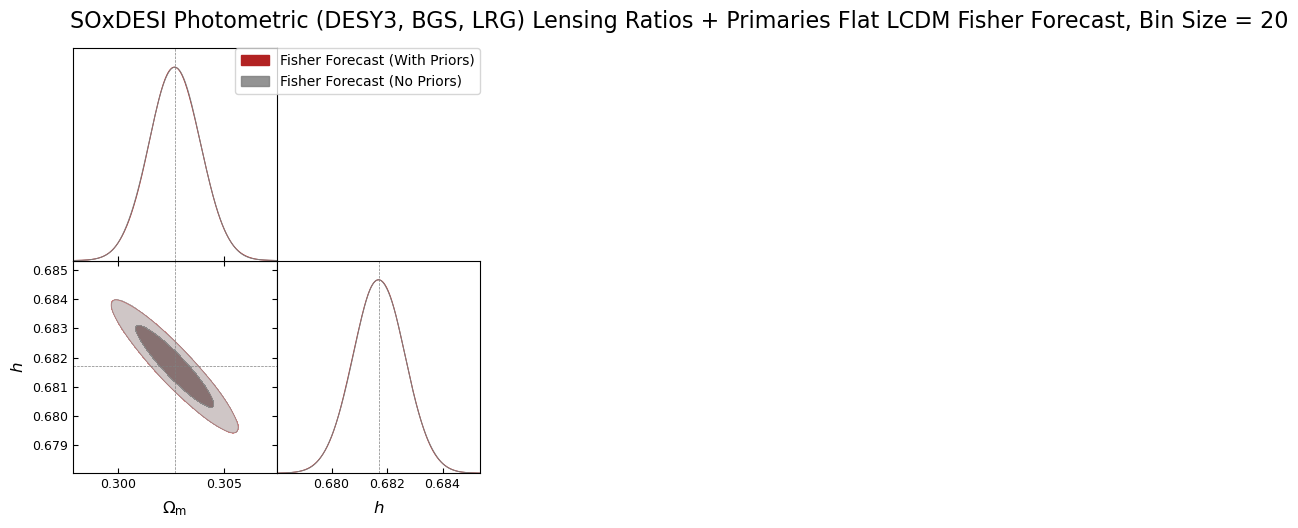

| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2532\pm 0.0011$ | $\Omega_{c} = 0.2532^{+0.0021}_{-0.0021}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2532\pm 0.0011$ | $\Omega_{c} = 0.2532^{+0.0021}_{-0.0021}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04807\pm 0.00016$ | $\Omega_{b} = 0.04807^{+0.00032}_{-0.00032}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04807\pm 0.00016$ | $\Omega_{b} = 0.04807^{+0.00032}_{-0.00032}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.68170\pm 0.00093$ | $h = 0.6817^{+0.0018}_{-0.0018}$ |
|  | Fisher Forecast (No Priors) | $h = 0.68170\pm 0.00094$ | $h = 0.6817^{+0.0018}_{-0.0018}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.1220\pm 0.0045\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.1220^{+0.0089}_{-0.0088}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.1220\pm 0.0045\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.1220^{+0.0089}_{-0.0089}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9693\pm 0.0025$ | $n_s = 0.9693^{+0.0049}_{-0.0049}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9693\pm 0.0025$ | $n_s = 0.9693^{+0.0049}_{-0.0049}$ |
| --- | --- | --- | --- |

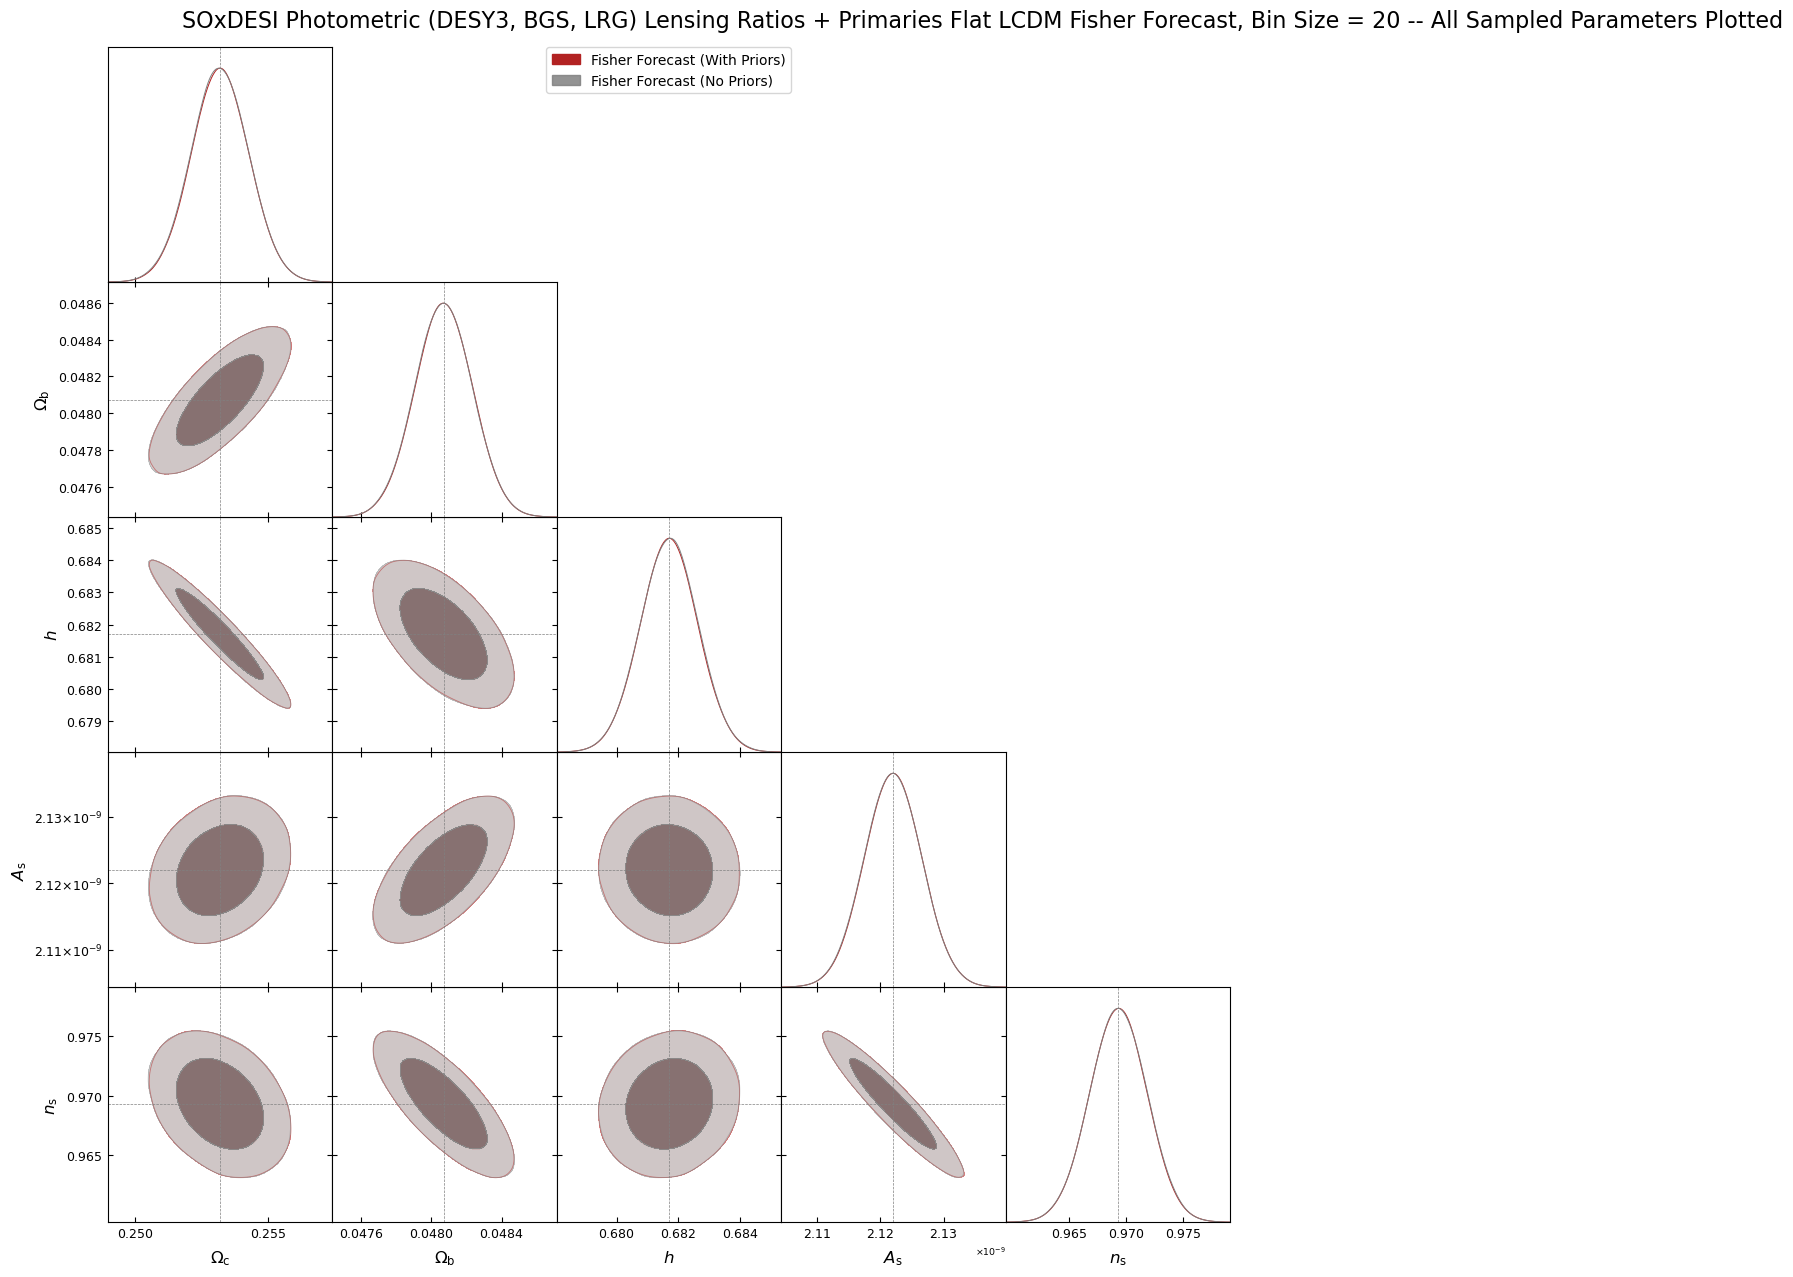

total_time:  0:07:08.401582


In [24]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_LCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_LCDM_LRP_Photo_BGS_LRG_DESY3_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_LCDM_LRP_Photo_BGS_LRG_DESY3_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, BGS, LRG) Lensing Ratios + Primaries Flat LCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, BGS, LRG) Lensing Ratios + Primaries Flat LCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Curved LCDM

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'Omega_k', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LR_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h Omega_k A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LR_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h Omega_k A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios Curved LCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios Curved LCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_curved_lcdm_fisher_forecast_bin_size_=_20.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3034\pm 0.0091$ | $\Omega_m = 0.303^{+0.018}_{-0.018}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3034\pm 0.0091$ | $\Omega_m = 0.303^{+0.018}_{-0.018}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.685\pm 0.012$ | $h = 0.685^{+0.023}_{-0.023}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.012$ | $h = 0.685^{+0.023}_{-0.023}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0023\pm 0.0030$ | $\Omega_k = 0.0023^{+0.0058}_{-0.0059}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0030$ | $\Omega_k = 0.0023^{+0.0058}_{-0.0059}$ |
| --- | --- | --- | --- |

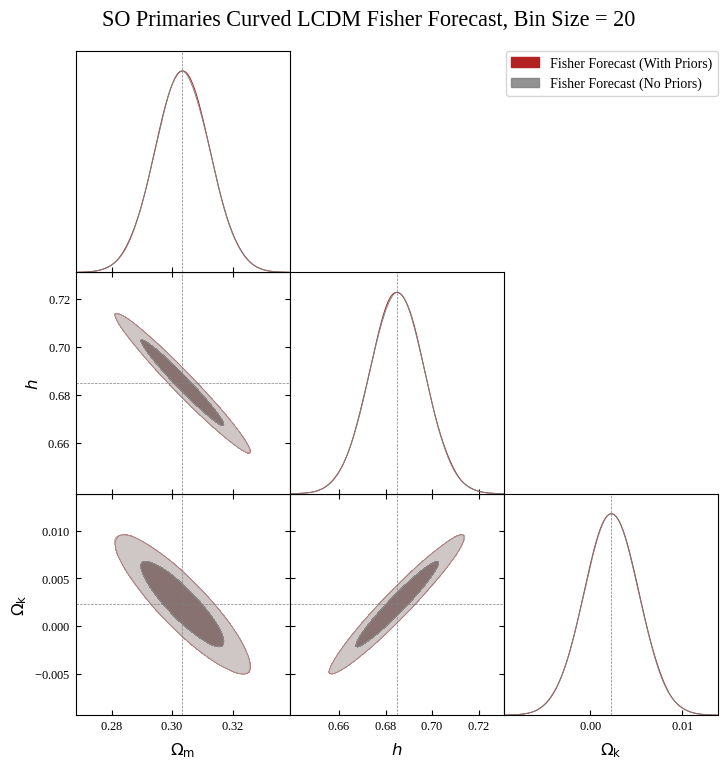

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_curved_lcdm_fisher_forecast_bin_size_=_20_--_all_sampled_parameters_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2547\pm 0.0075$ | $\Omega_{c} = 0.255^{+0.015}_{-0.015}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2547\pm 0.0075$ | $\Omega_{c} = 0.255^{+0.015}_{-0.015}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.0473\pm 0.0016$ | $\Omega_{b} = 0.0473^{+0.0032}_{-0.0032}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.0473\pm 0.0016$ | $\Omega_{b} = 0.0473^{+0.0032}_{-0.0032}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.685\pm 0.012$ | $h = 0.685^{+0.023}_{-0.023}$ |
|  | Fisher Forecast (No Priors) | $h = 0.685\pm 0.012$ | $h = 0.685^{+0.023}_{-0.023}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = 0.0023\pm 0.0030$ | $\Omega_k = 0.0023^{+0.0059}_{-0.0058}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0023\pm 0.0030$ | $\Omega_k = 0.0023^{+0.0059}_{-0.0059}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.1150\pm 0.0064\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.115^{+0.012}_{-0.012}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.1150\pm 0.0064\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.115^{+0.012}_{-0.012}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9649\pm 0.0033$ | $n_s = 0.9649^{+0.0065}_{-0.0065}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9649\pm 0.0033$ | $n_s = 0.9649^{+0.0065}_{-0.0065}$ |
| --- | --- | --- | --- |

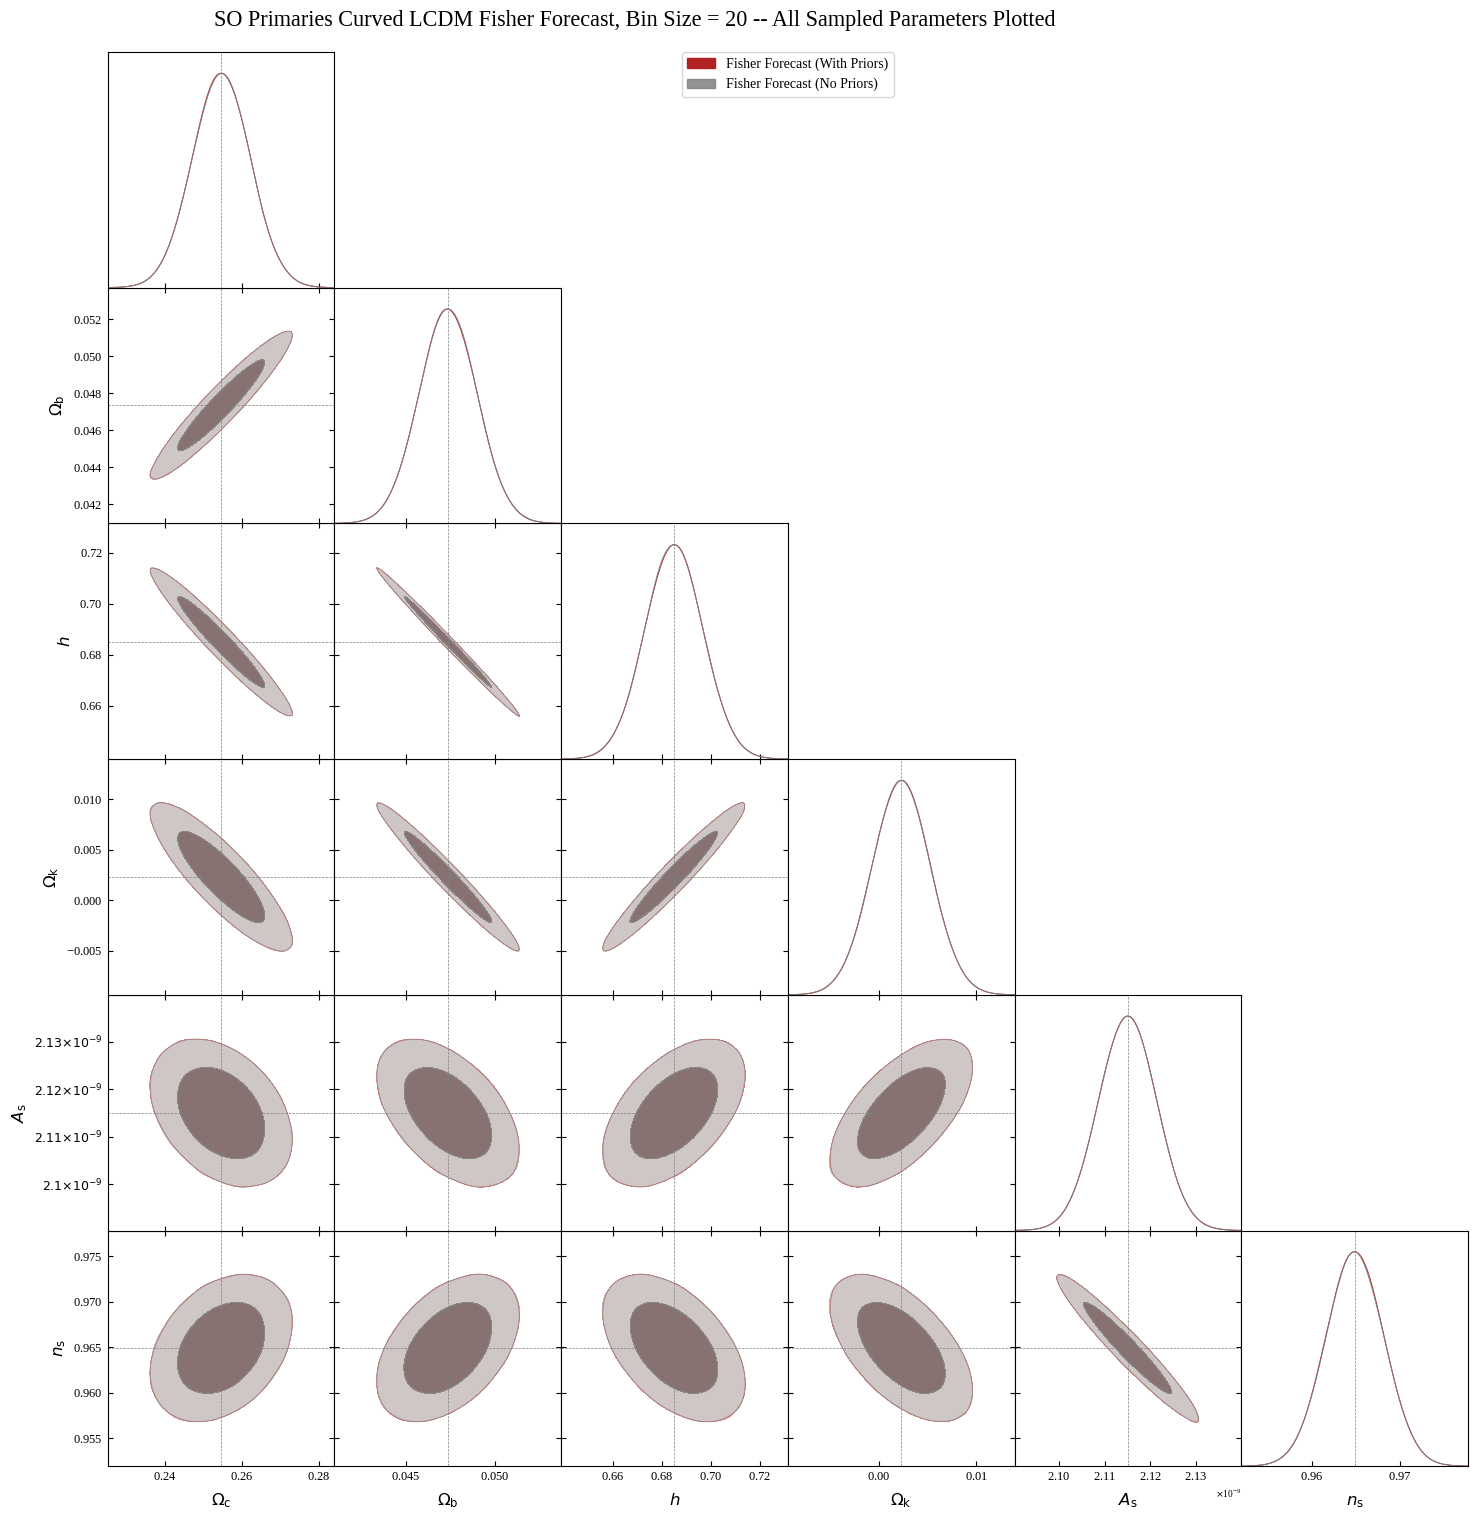

total_time:  0:04:08.860063


In [42]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=HSC_dist_0_3,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'Omega_k', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_Primaries_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h Omega_k A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_Primaries_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h Omega_k A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Curved LCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Curved LCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_LCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'Omega_k', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'Omega_k']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_LCDM_LRP_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h Omega_k A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_LCDM_LRP_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h Omega_k A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Curved LCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Curved LCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Flat wCDM

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LR_Photo_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, A_s n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LR_Photo_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, A_s n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios Flat wCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios Flat wCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_flat_wcdm_fisher_forecast_bin_size_=_20.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3098\pm 0.0023$ | $\Omega_m = 0.3098^{+0.0045}_{-0.0045}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3098\pm 0.0023$ | $\Omega_m = 0.3098^{+0.0045}_{-0.0045}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6734\pm 0.0028$ | $h = 0.6734^{+0.0054}_{-0.0054}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6734\pm 0.0028$ | $h = 0.6734^{+0.0054}_{-0.0054}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.971\pm 0.015$ | $w_0 = -0.971^{+0.029}_{-0.029}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.971\pm 0.015$ | $w_0 = -0.971^{+0.029}_{-0.029}$ |
| --- | --- | --- | --- |

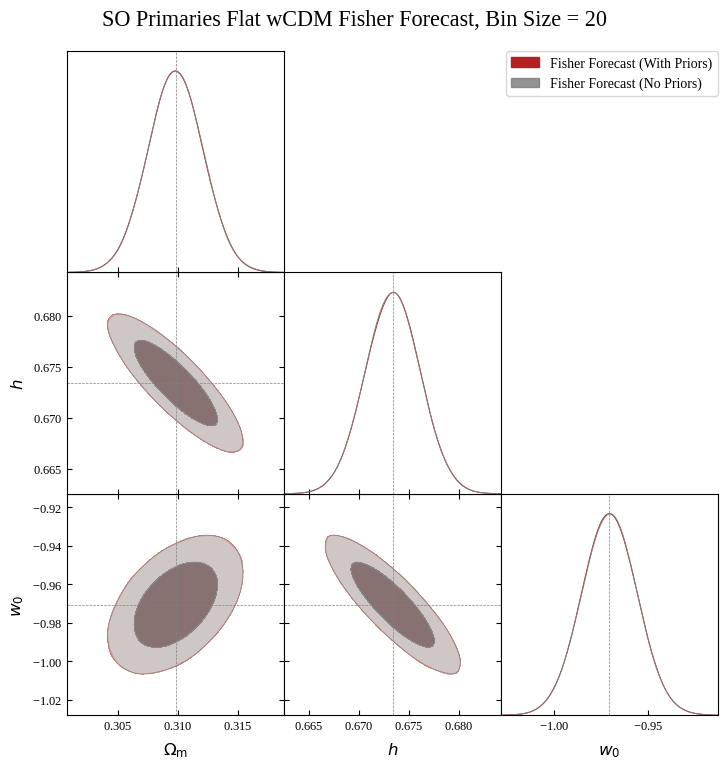

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_flat_wcdm_fisher_forecast_bin_size_=_20_--_all_sampled_parameters_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2591\pm 0.0020$ | $\Omega_{c} = 0.2591^{+0.0039}_{-0.0039}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2591\pm 0.0020$ | $\Omega_{c} = 0.2591^{+0.0039}_{-0.0039}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04929\pm 0.00046$ | $\Omega_{b} = 0.04929^{+0.00090}_{-0.00090}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04929\pm 0.00046$ | $\Omega_{b} = 0.04929^{+0.00090}_{-0.00090}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6734\pm 0.0028$ | $h = 0.6734^{+0.0054}_{-0.0054}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6734\pm 0.0028$ | $h = 0.6734^{+0.0054}_{-0.0054}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.971\pm 0.015$ | $w_0 = -0.971^{+0.029}_{-0.029}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.971\pm 0.015$ | $w_0 = -0.971^{+0.029}_{-0.029}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.1270\pm 0.0050\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.1270^{+0.0097}_{-0.0097}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.1270\pm 0.0049\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.1270^{+0.0097}_{-0.0097}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9699\pm 0.0027$ | $n_s = 0.9699^{+0.0053}_{-0.0053}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9699\pm 0.0027$ | $n_s = 0.9699^{+0.0053}_{-0.0053}$ |
| --- | --- | --- | --- |

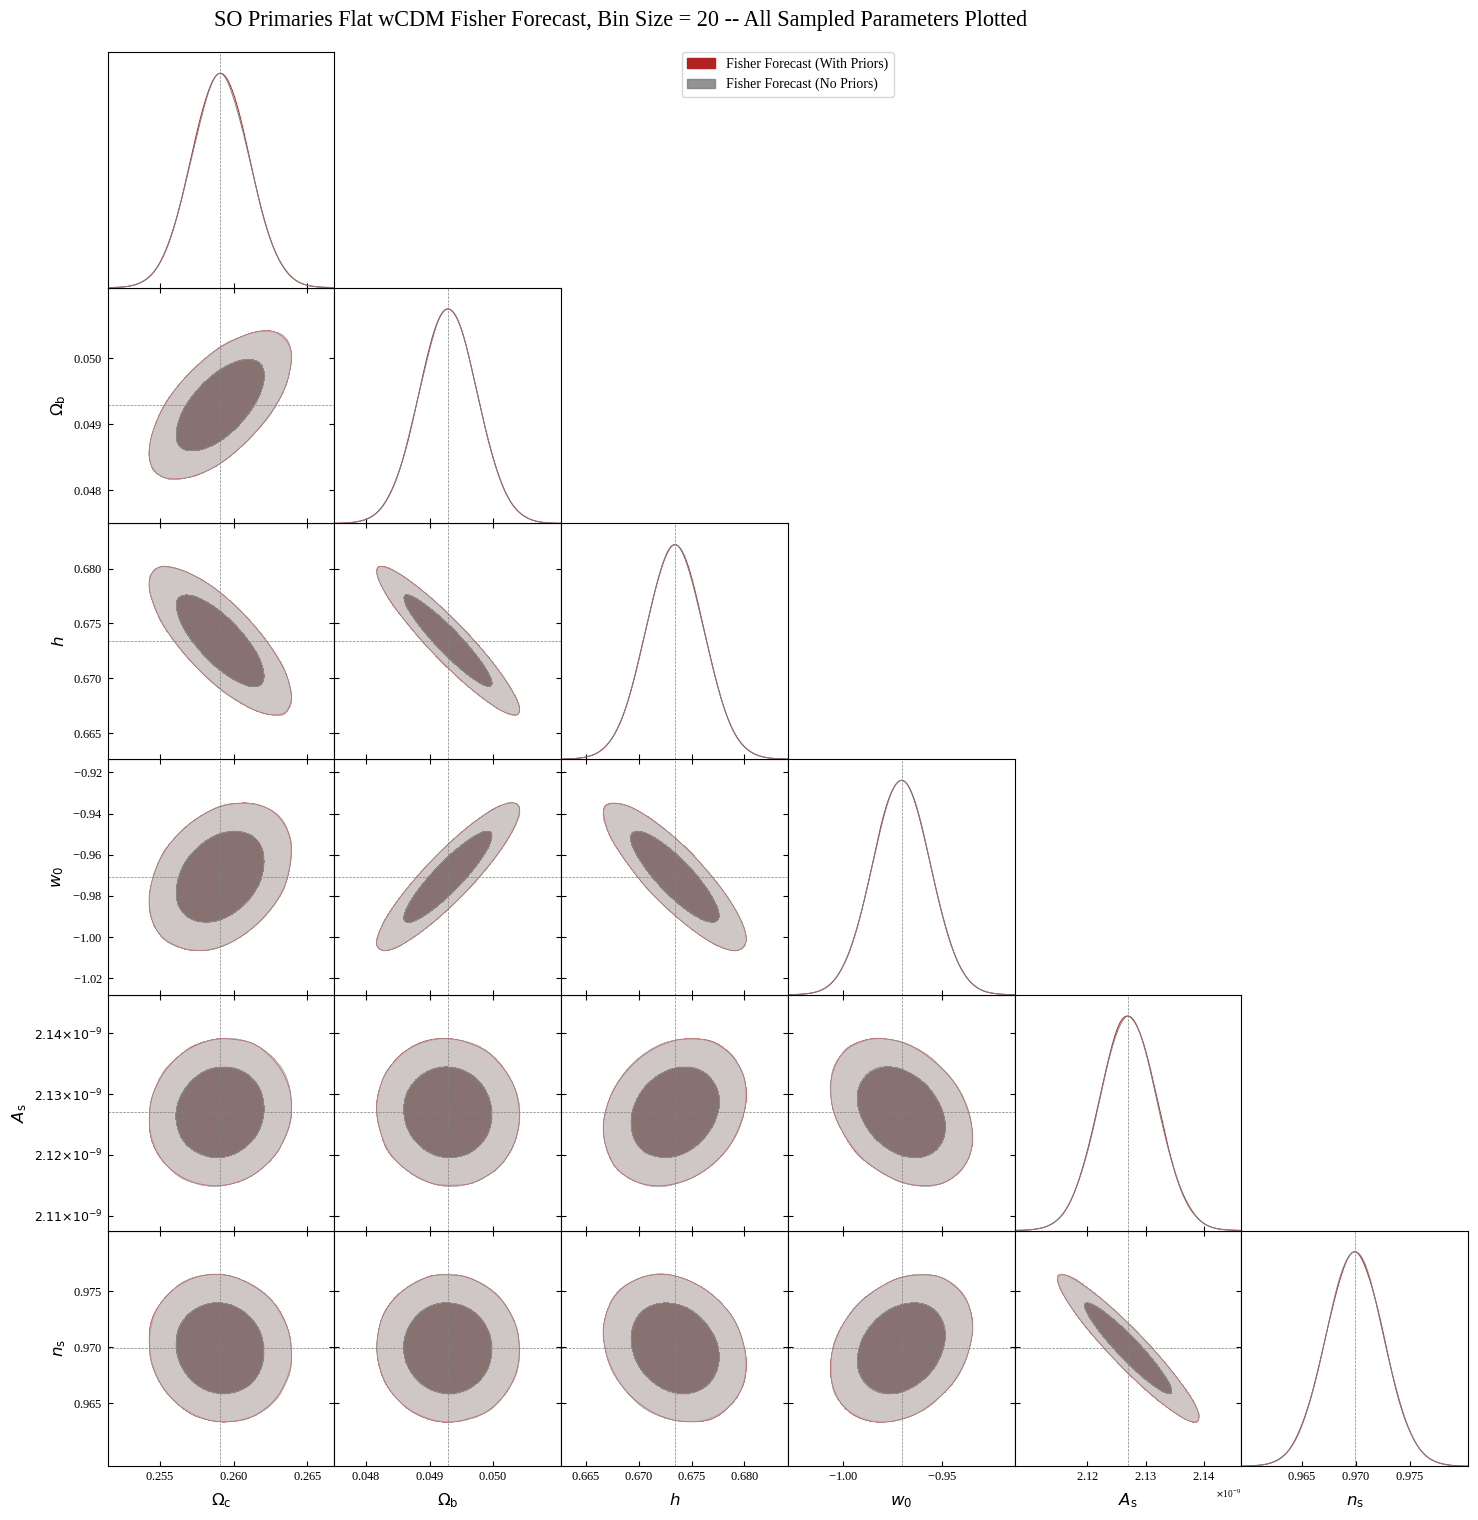

total_time:  0:03:57.775030


In [21]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=HSC_dist_0_3,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_Primaries_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_Primaries_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Flat wCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Flat wCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_wCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_wCDM_LRP_Photo_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, A_s n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_wCDM_LRP_Photo_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, A_s n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Flat wCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

# Call the unified class method to load, sample, overlay, and plot everything
g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Flat wCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Flat w0waCDM

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LR_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LR_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios Flat w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios Flat w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_flat_w0wacdm_fisher_forecast_bin_size_=_20.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3189\pm 0.0066$ | $\Omega_m = 0.319^{+0.013}_{-0.013}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3189\pm 0.0067$ | $\Omega_m = 0.319^{+0.013}_{-0.013}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0070$ | $h = 0.667^{+0.014}_{-0.014}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0070$ | $h = 0.667^{+0.014}_{-0.014}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.074$ | $w_0 = -0.75^{+0.14}_{-0.14}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.073$ | $w_0 = -0.75^{+0.14}_{-0.14}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.31$ | $w_a = -0.86^{+0.61}_{-0.60}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.31$ | $w_a = -0.86^{+0.60}_{-0.60}$ |
| --- | --- | --- | --- |

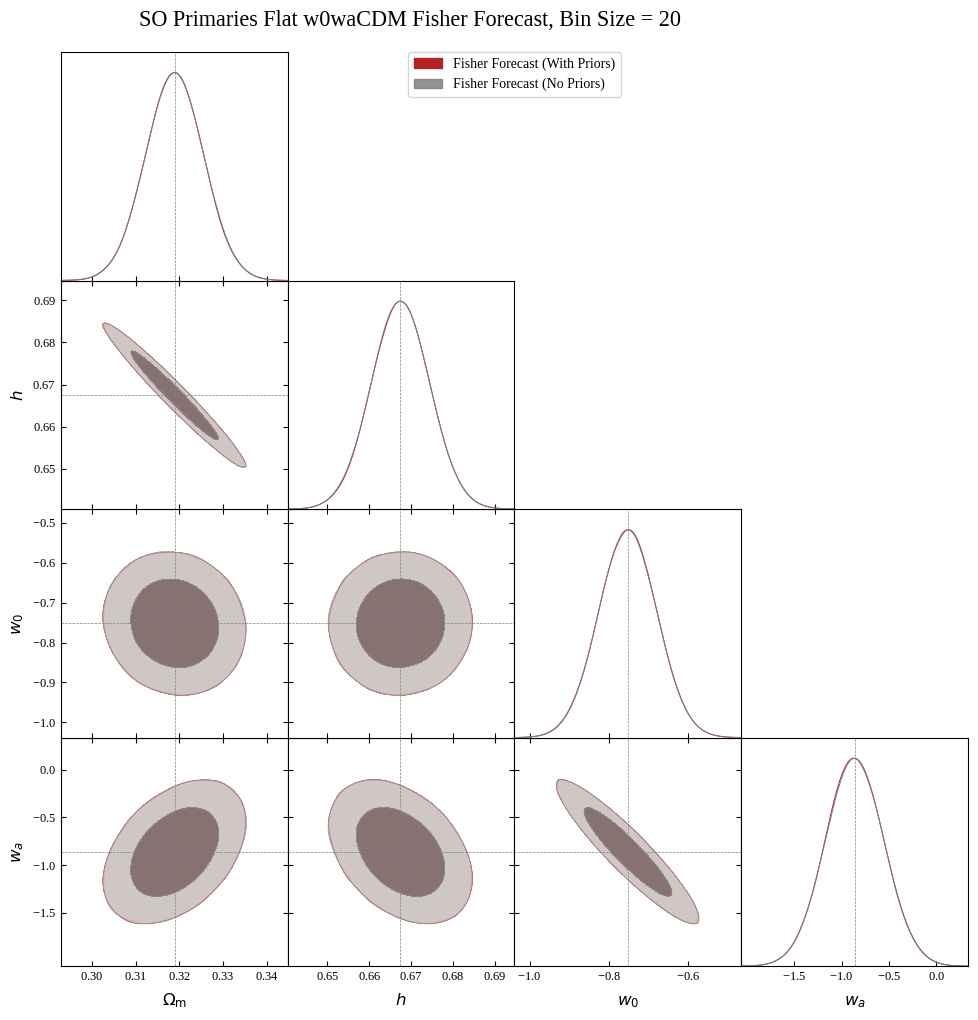

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_flat_w0wacdm_fisher_forecast_bin_size_=_20_--_all_sampled_parameters_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2676\pm 0.0056$ | $\Omega_{c} = 0.268^{+0.011}_{-0.011}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2676\pm 0.0056$ | $\Omega_{c} = 0.268^{+0.011}_{-0.011}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.0499\pm 0.0011$ | $\Omega_{b} = 0.0499^{+0.0021}_{-0.0021}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.0499\pm 0.0011$ | $\Omega_{b} = 0.0499^{+0.0021}_{-0.0021}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0070$ | $h = 0.667^{+0.014}_{-0.014}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0070$ | $h = 0.667^{+0.014}_{-0.014}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.074$ | $w_0 = -0.75^{+0.14}_{-0.14}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.074$ | $w_0 = -0.75^{+0.14}_{-0.14}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.31$ | $w_a = -0.86^{+0.60}_{-0.61}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.31$ | $w_a = -0.86^{+0.60}_{-0.61}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.0940\pm 0.0049\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0097}_{-0.0097}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.0940\pm 0.0049\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0097}_{-0.0097}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9654\pm 0.0027$ | $n_s = 0.9654^{+0.0053}_{-0.0053}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9654\pm 0.0027$ | $n_s = 0.9654^{+0.0053}_{-0.0053}$ |
| --- | --- | --- | --- |

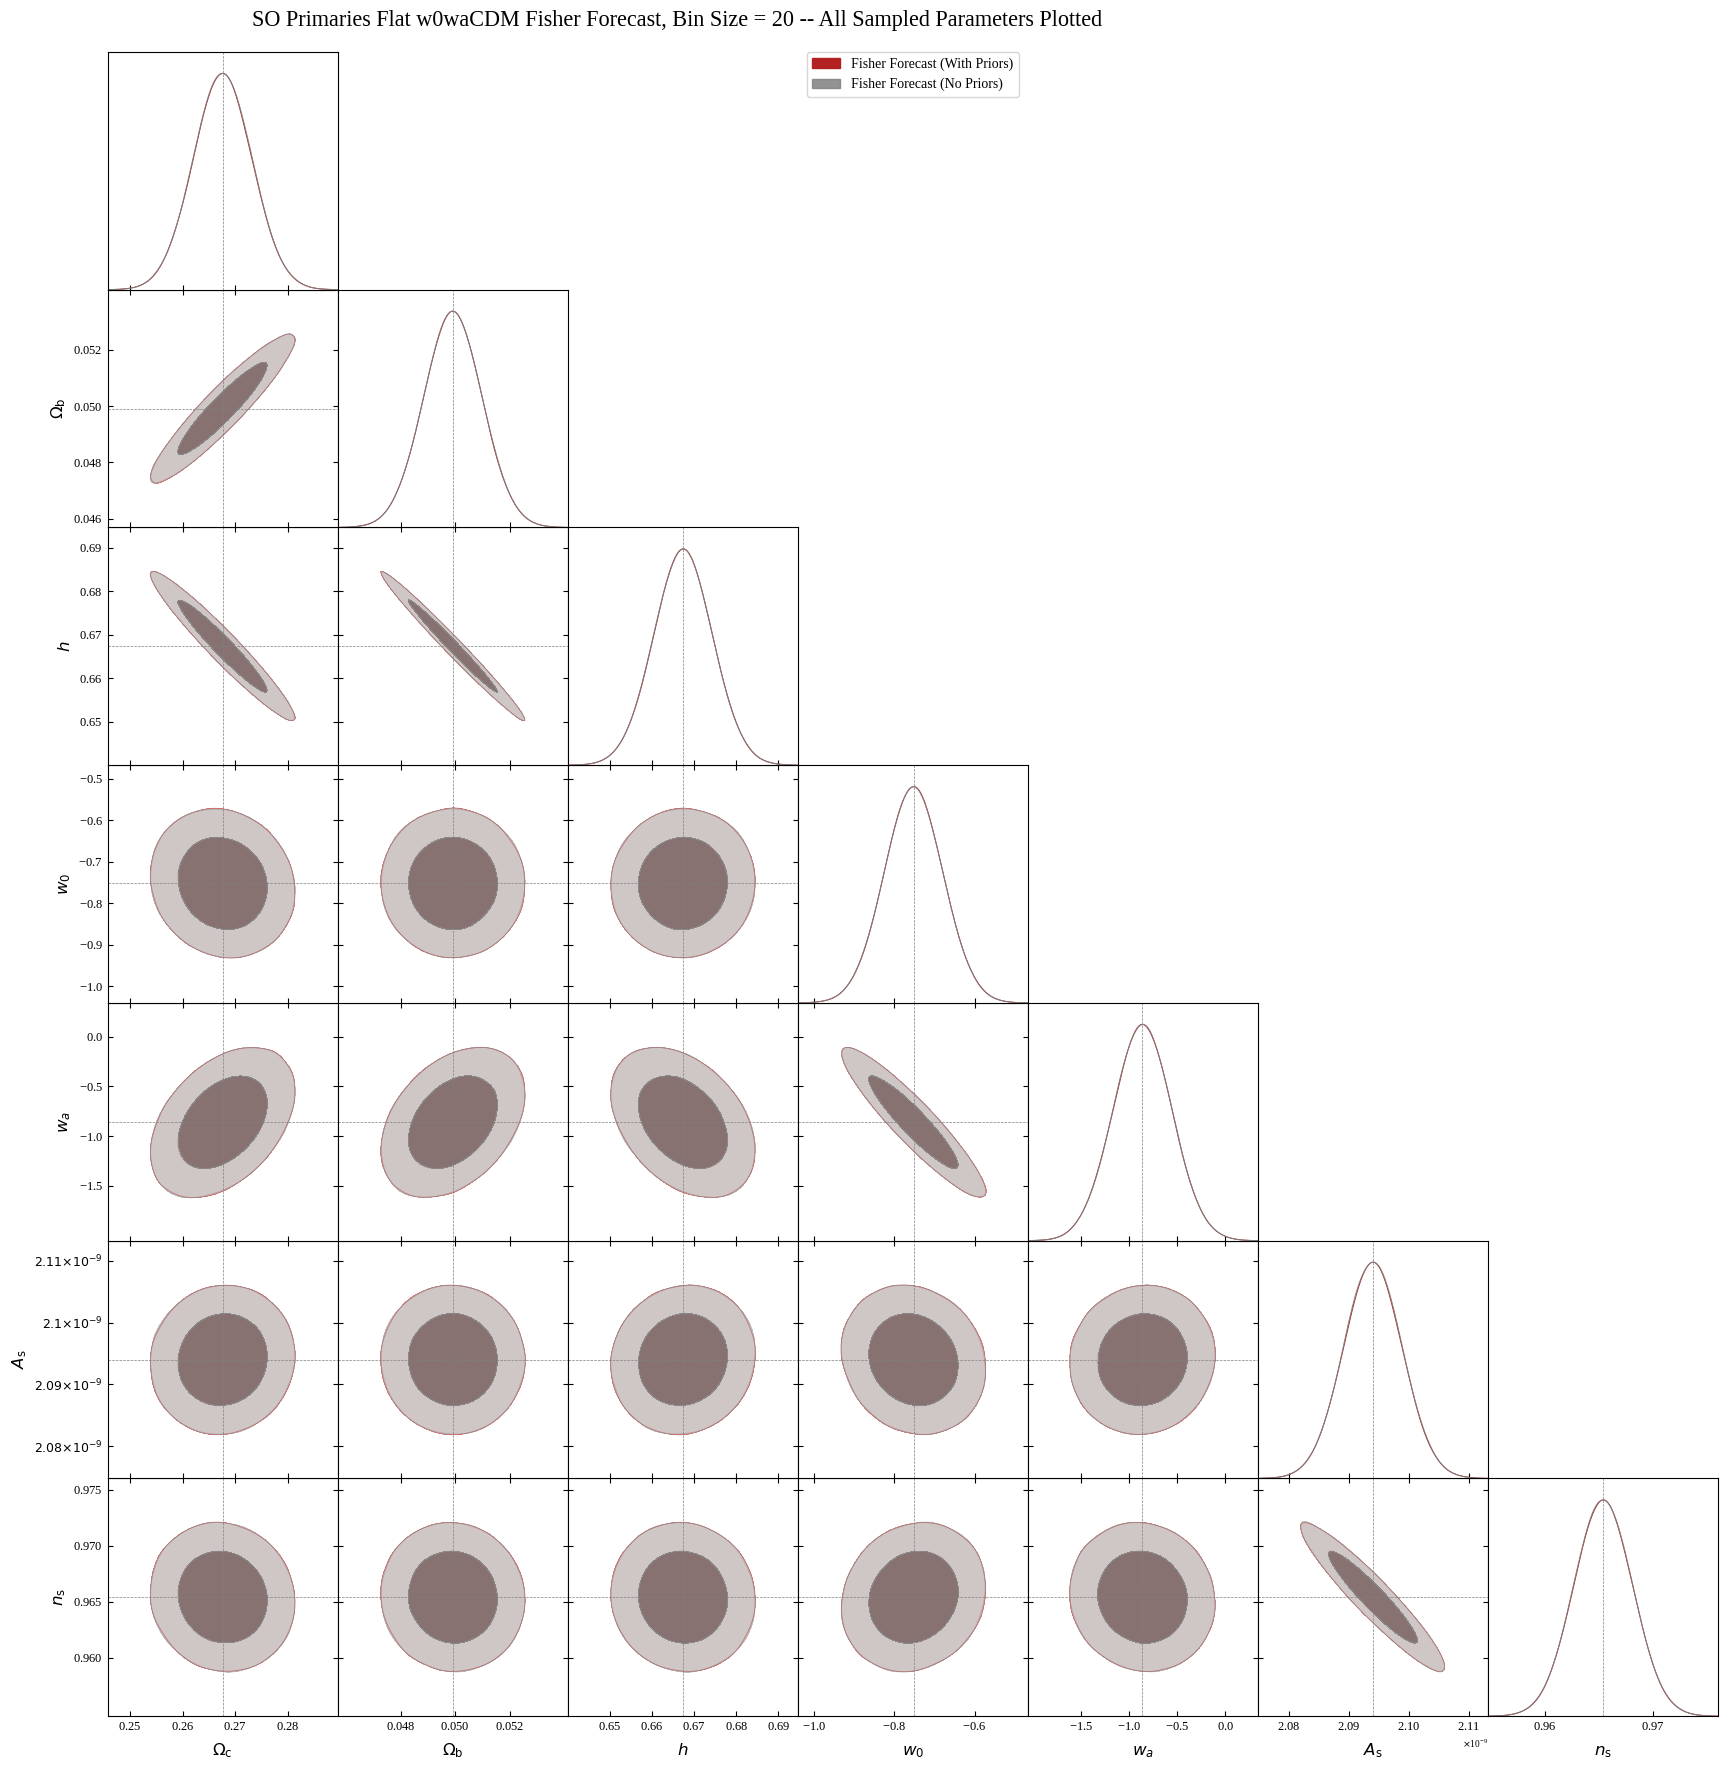

total_time:  0:04:38.198616


In [77]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=HSC_dist_0_3,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_Primaries_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_Primaries_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

#### Curved w0waCDM

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=None,
    cmb_noise_EE=None,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL'],
    cmb_primaries=False,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'Omega_k', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LR_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h Omega_k w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LR_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h Omega_k w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios Curved w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios Curved w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_curved_w0wacdm_fisher_forecast_bin_size_=_20.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.289^{+0.082}_{-0.11}$ | $\Omega_m = 0.29^{+0.16}_{-0.16}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = \Omega_\mathrm{m} < 0.391$ | $\Omega_m = \Omega_\mathrm{m} < 0.572$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.700^{+0.11}_{-0.086}$ | $h = 0.70^{+0.17}_{-0.17}$ |
|  | Fisher Forecast (No Priors) | $h = 0.67\pm 0.16$ | $h = 0.67^{+0.32}_{-0.31}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.0009\pm 0.0043$ | $\Omega_k = -0.0009^{+0.0084}_{-0.0081}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0008\pm 0.0072$ | $\Omega_k = 0.001^{+0.014}_{-0.014}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.17^{+0.82}_{-0.31}$ | $w_0 = -1.17^{+0.86}_{-0.94}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.8\pm 1.5$ | $w_0 = -0.8^{+3.0}_{-3.0}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.2\pm 1.5$ | $w_a = 0.2^{+2.7}_{-2.5}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.8\pm 4.0$ | $w_a = -0.8^{+7.8}_{-7.8}$ |
| --- | --- | --- | --- |

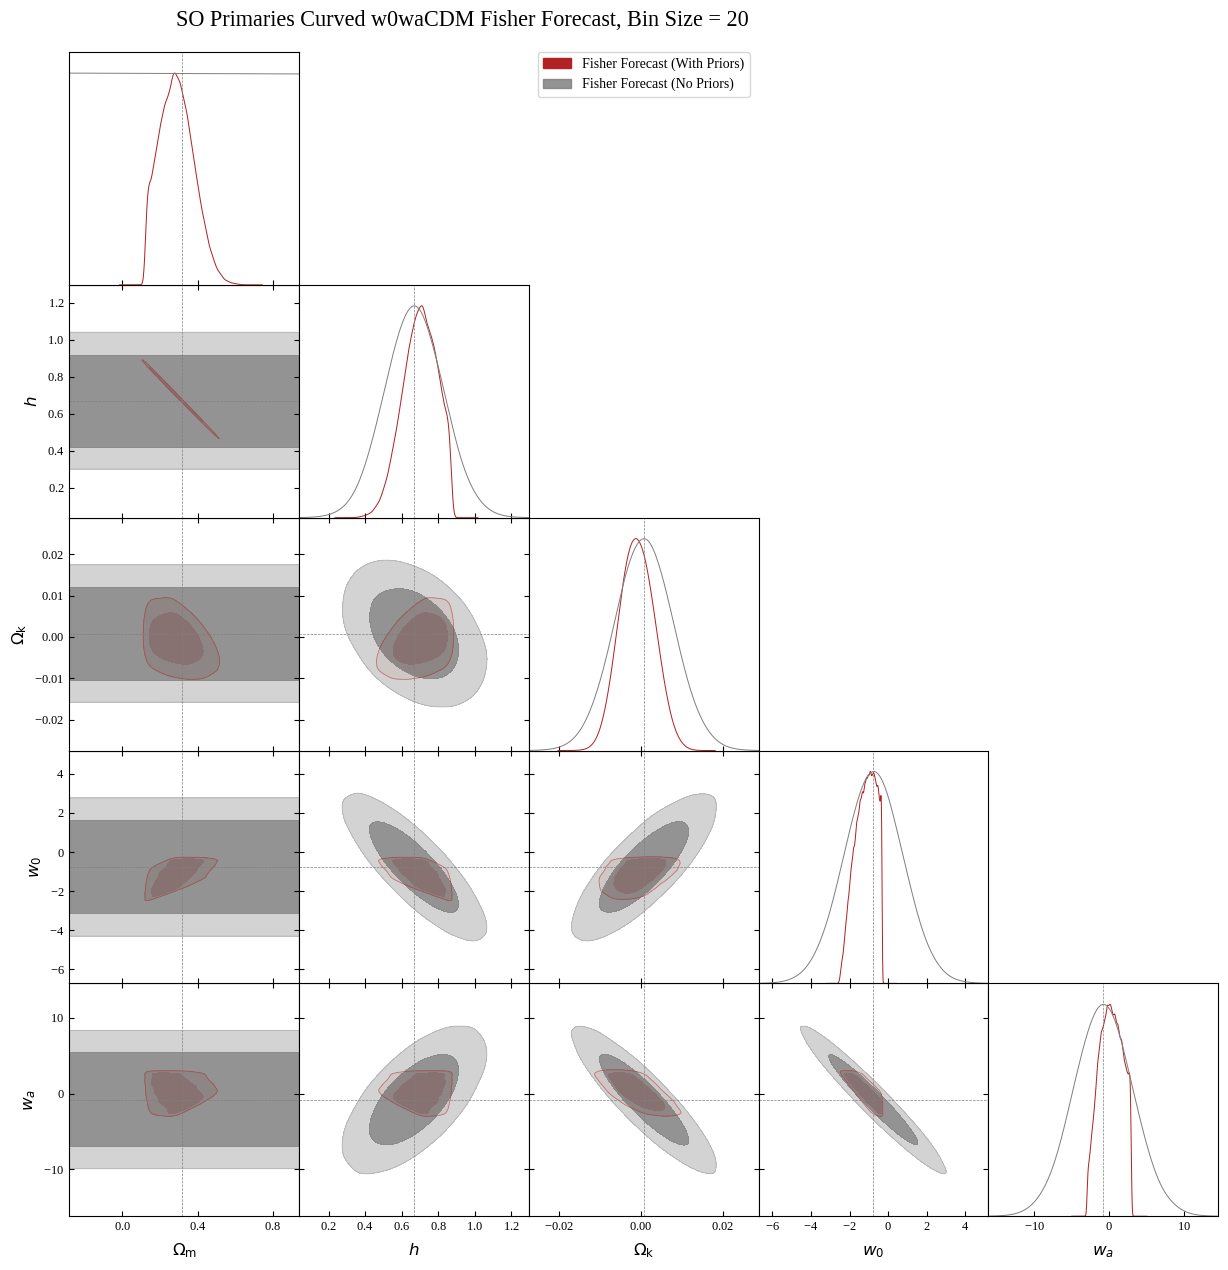

Plot successfully saved to: plots/Fisher Forecasts/so_primaries_curved_w0wacdm_fisher_forecast_bin_size_=_20_--_all_sampled_parameters_plotted.pdf


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.242^{+0.070}_{-0.089}$ | $\Omega_{c} = 0.24^{+0.14}_{-0.14}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.27\pm 0.13$ | $\Omega_{c} = 0.27^{+0.26}_{-0.25}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.045^{+0.013}_{-0.016}$ | $\Omega_{b} = 0.045^{+0.025}_{-0.025}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.050\pm 0.024$ | $\Omega_{b} = 0.050^{+0.047}_{-0.047}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.701^{+0.11}_{-0.087}$ | $h = 0.70^{+0.17}_{-0.17}$ |
|  | Fisher Forecast (No Priors) | $h = 0.67\pm 0.16$ | $h = 0.67^{+0.32}_{-0.32}$ |
| --- | --- | --- | --- |
| **$\Omega_k$** | Fisher Forecast (With Priors) | $\Omega_k = -0.0009\pm 0.0043$ | $\Omega_k = -0.0009^{+0.0084}_{-0.0082}$ |
|  | Fisher Forecast (No Priors) | $\Omega_k = 0.0008\pm 0.0072$ | $\Omega_k = 0.001^{+0.014}_{-0.014}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -1.17^{+0.82}_{-0.31}$ | $w_0 = -1.17^{+0.87}_{-0.95}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.8\pm 1.5$ | $w_0 = -0.8^{+3.0}_{-3.0}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = 0.2\pm 1.5$ | $w_a = 0.2^{+2.7}_{-2.5}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.8\pm 4.0$ | $w_a = -0.8^{+7.8}_{-7.8}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.0947\pm 0.0063\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.095^{+0.012}_{-0.012}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.0950\pm 0.0064\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.095^{+0.012}_{-0.012}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9641\pm 0.0033$ | $n_s = 0.9641^{+0.0065}_{-0.0065}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9644\pm 0.0035$ | $n_s = 0.9644^{+0.0068}_{-0.0068}$ |
| --- | --- | --- | --- |

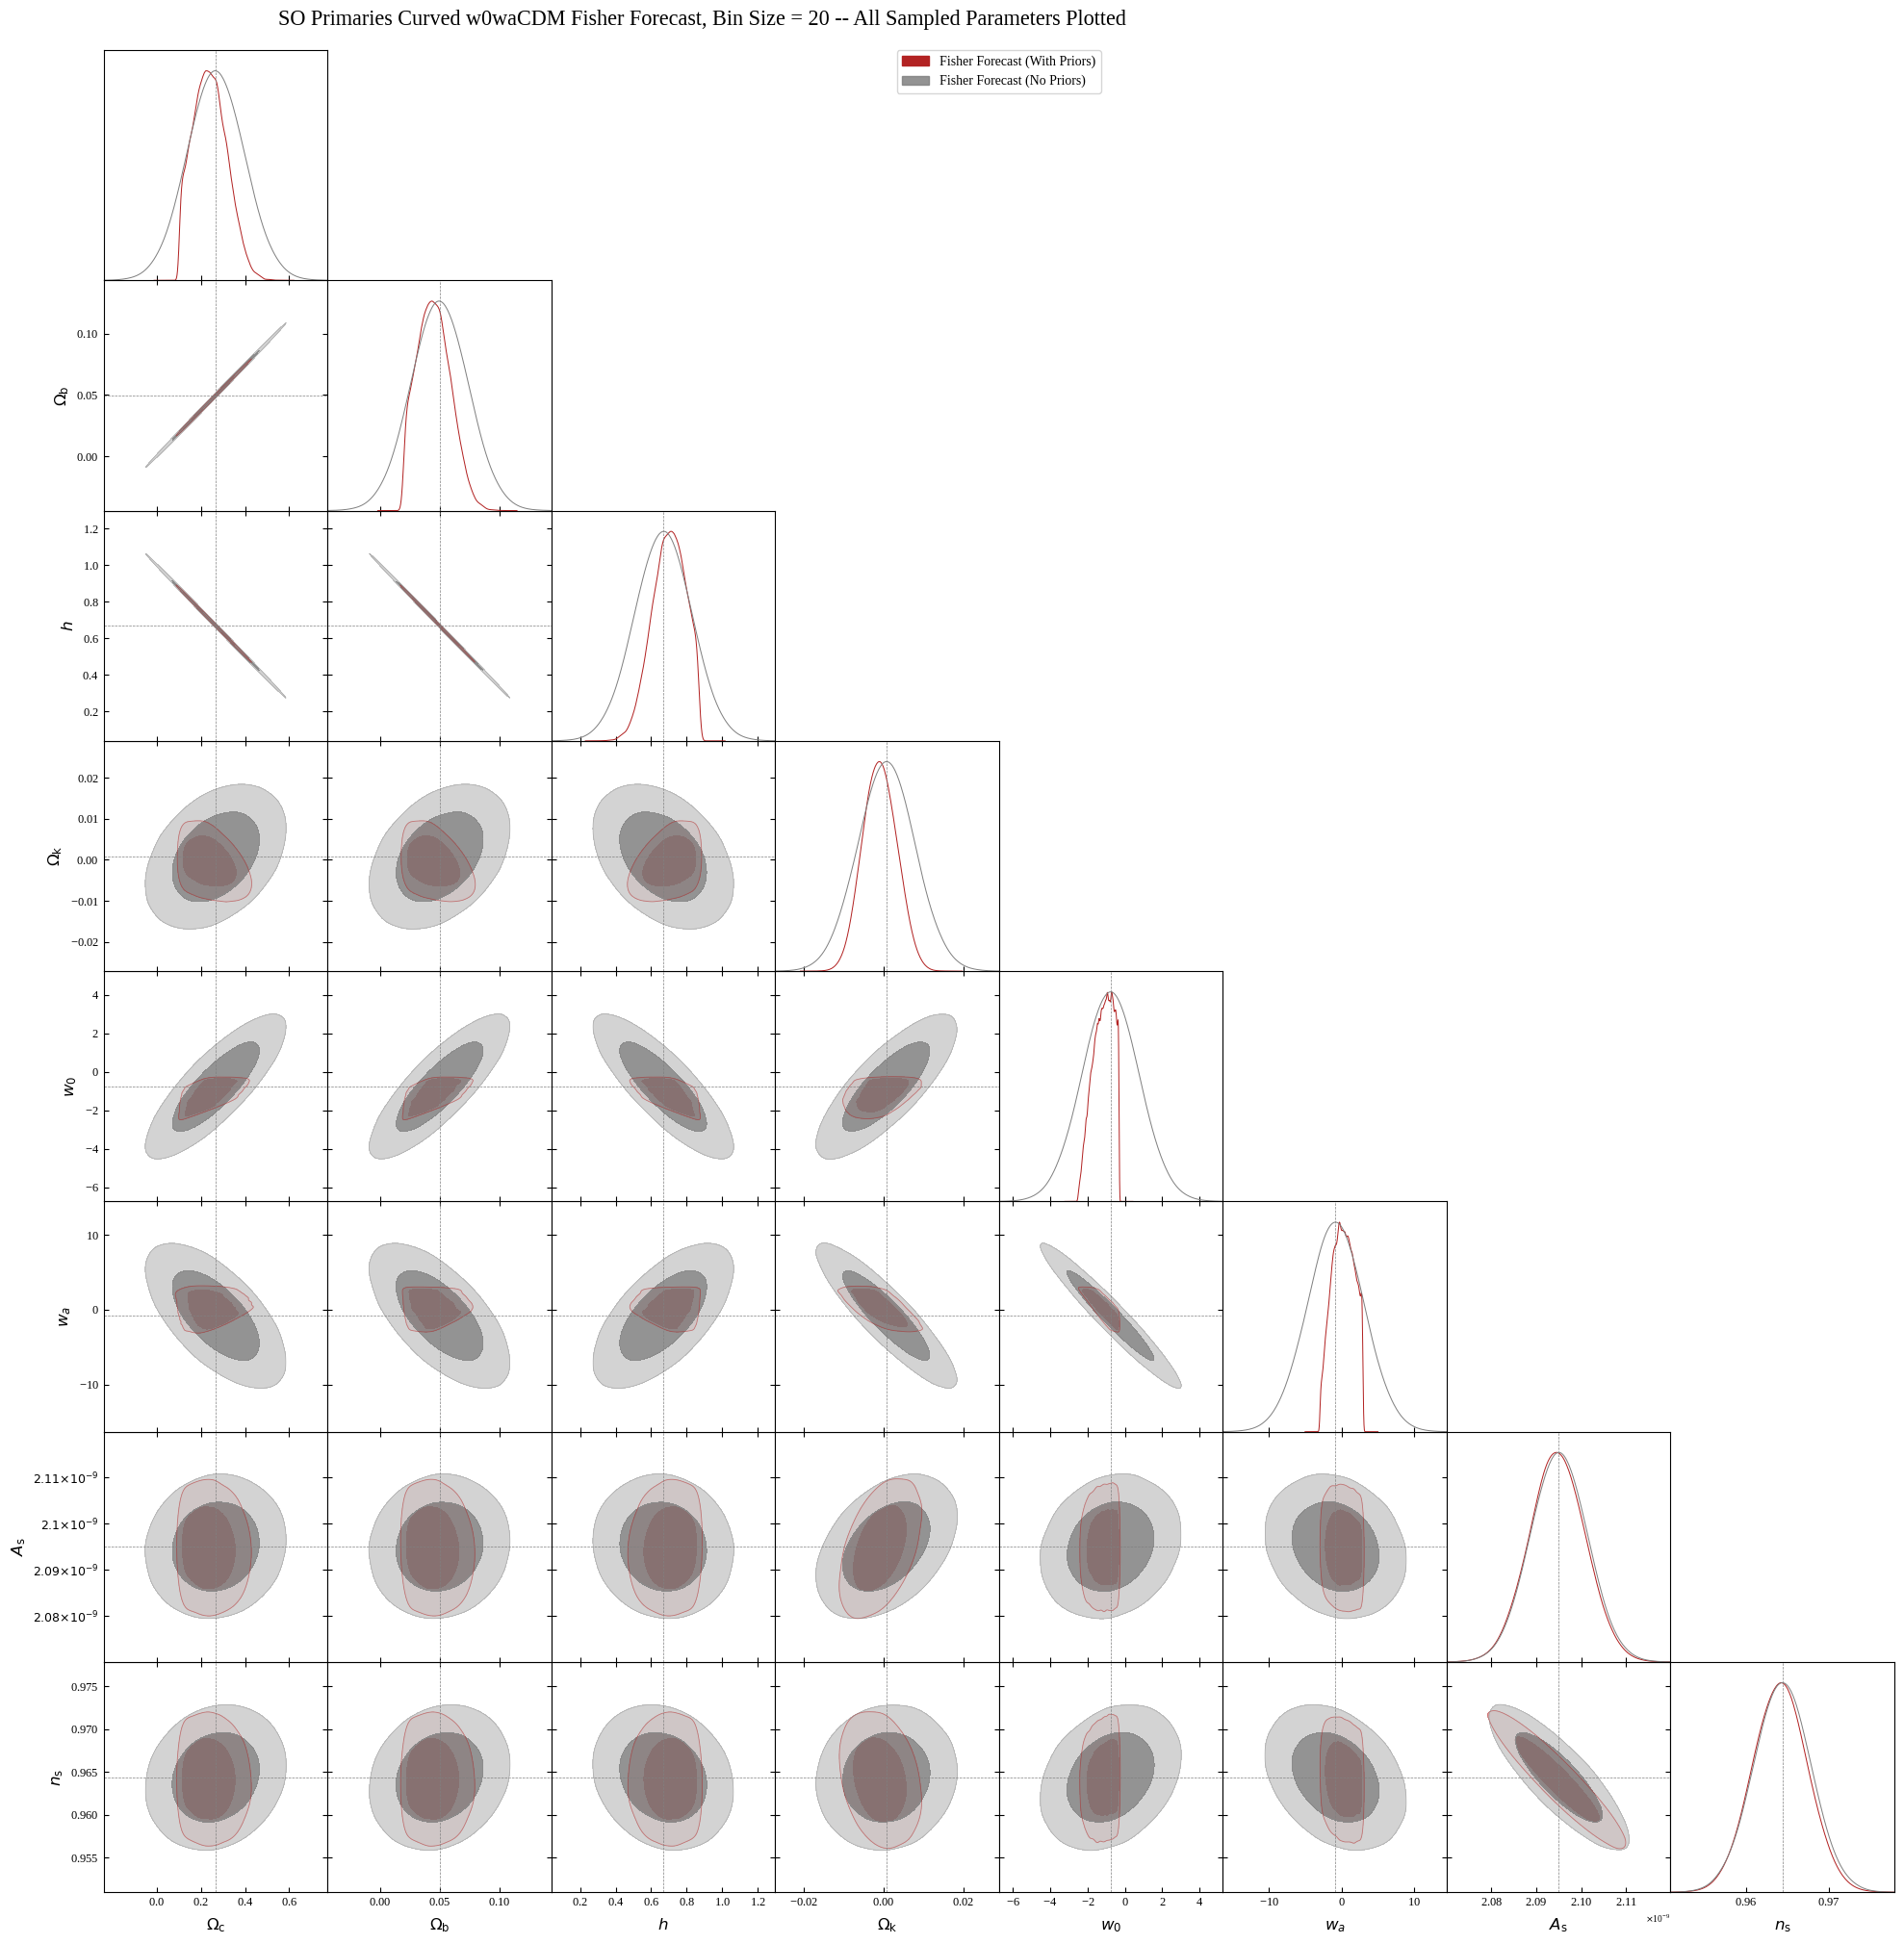

total_time:  0:05:28.048102


In [27]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=HSC_dist_0_3,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DESI_shape_noise,
    desired_spectra=['TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'Omega_k', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_Primaries_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h Omega_k w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_Primaries_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h Omega_k w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Curved w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SO Primaries Curved w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = True,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=curved_w0waCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator=None,
    boost_emulator=None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['TT', 'EE', 'CG', 'GL'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'Omega_k', 'w0', 'wa', 'A_s']
params_to_plot = ['Omega_m', 'h', 'Omega_k', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Curved_w0waCDM_LRP_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h Omega_k w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Curved_w0waCDM_LRP_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h Omega_k w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, Omega_k, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Curved w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Curved w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

### w0wa Dataset Comparison -- BGS, LRG, BGS + LRG

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=BGS_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_DESY3_BGS_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_DESY3_BGS_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_DESY3_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_DESY3_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

In [ ]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=BGS_LRG_distributions,
    source_data=DES_source_data,
    binsize=20,
    l_min =40,
    n_ell = 5000,
    f_sky_c = 0.4,
    f_sky_g = 0.4,
    f_sky_l = 0.1,
    f_sky_c_g = 0.295,
    f_sky_c_l = 0.0306,
    f_sky_g_l = 0.0306,
    f_sky_c_g_l = 0.0306,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_LRG_shot_noise,
    shape_noise_source=DES_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_DESY3_BGS_LRG_Binsize=20.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_DESY3_BGS_LRG_Binsize=20.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (DESY3, LRG, BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 20 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

## Splitting Bins

In [45]:
def split_combined_array_by_equal_area(combined_array, num_subbins=5):
    """
    Split each input n(z) into equal-area sub-bins.

    Parameters
    ----------
    combined_array : ndarray
        First column is z, remaining columns are parent n(z) bins.
    num_subbins : int
        Number of equal-area sub-bins per parent bin.

    Returns
    -------
    ndarray
        First column is z, remaining columns are normalized sub-bin n(z).
    """

    z = combined_array[:, 0]
    new_cols = [z]

    for b in range(1, combined_array.shape[1]):
        nz = combined_array[:, b]

        # Restrict to the nonzero support
        active = nz > 1e-4 * nz.max()
        if not np.any(active):
            continue

        z_act = z[active]
        nz_act = nz[active]

        # Cumulative area
        cdf = cumulative_trapezoid(nz_act, x=z_act, initial=0)
        total_area = cdf[-1]

        # Equal-area boundaries
        targets = np.linspace(0, total_area, num_subbins + 1)
        z_cuts = np.interp(targets, cdf, z_act)

        print(f"\nParent bin {b}")

        for i in range(num_subbins):
            z0, z1 = z_cuts[i], z_cuts[i + 1]

            # Interior grid points
            mask = (z > z0) & (z < z1)

            # Build exact integration grid with interpolated endpoints
            z_sub = np.concatenate(([z0], z[mask], [z1]))
            nz_sub = np.concatenate((
                [np.interp(z0, z, nz)],
                nz[mask],
                [np.interp(z1, z, nz)]
            ))

            raw_area = simpson(nz_sub, x=z_sub)

            print(
                f"  Sub-bin {i+1}: area = {raw_area:.8f} "
                f"(target {total_area/num_subbins:.8f})"
            )

            # Normalize
            nz_sub /= raw_area

            # Interpolate back onto the original z grid
            nz_full = np.zeros_like(z)
            inside = (z >= z0) & (z <= z1)
            nz_full[inside] = np.interp(z[inside], z_sub, nz_sub)

            # Ensure normalization on the common grid
            area = simpson(nz_full, x=z)
            if area > 0:
                nz_full /= area

            new_cols.append(nz_full)

    return np.column_stack(new_cols)

In [46]:
# Split 2 BGS lens bins -> 6 lens sub-bins
bgs_6bins_array = split_combined_array_by_equal_area(BGS_LRG_distributions, num_subbins=3)


Parent bin 1
  Sub-bin 1: area = 0.33325128 (target 0.33325736)
  Sub-bin 2: area = 0.33327259 (target 0.33325736)
  Sub-bin 3: area = 0.33324829 (target 0.33325736)

Parent bin 2
  Sub-bin 1: area = 0.33331922 (target 0.33332702)
  Sub-bin 2: area = 0.33334260 (target 0.33332702)
  Sub-bin 3: area = 0.33331952 (target 0.33332702)


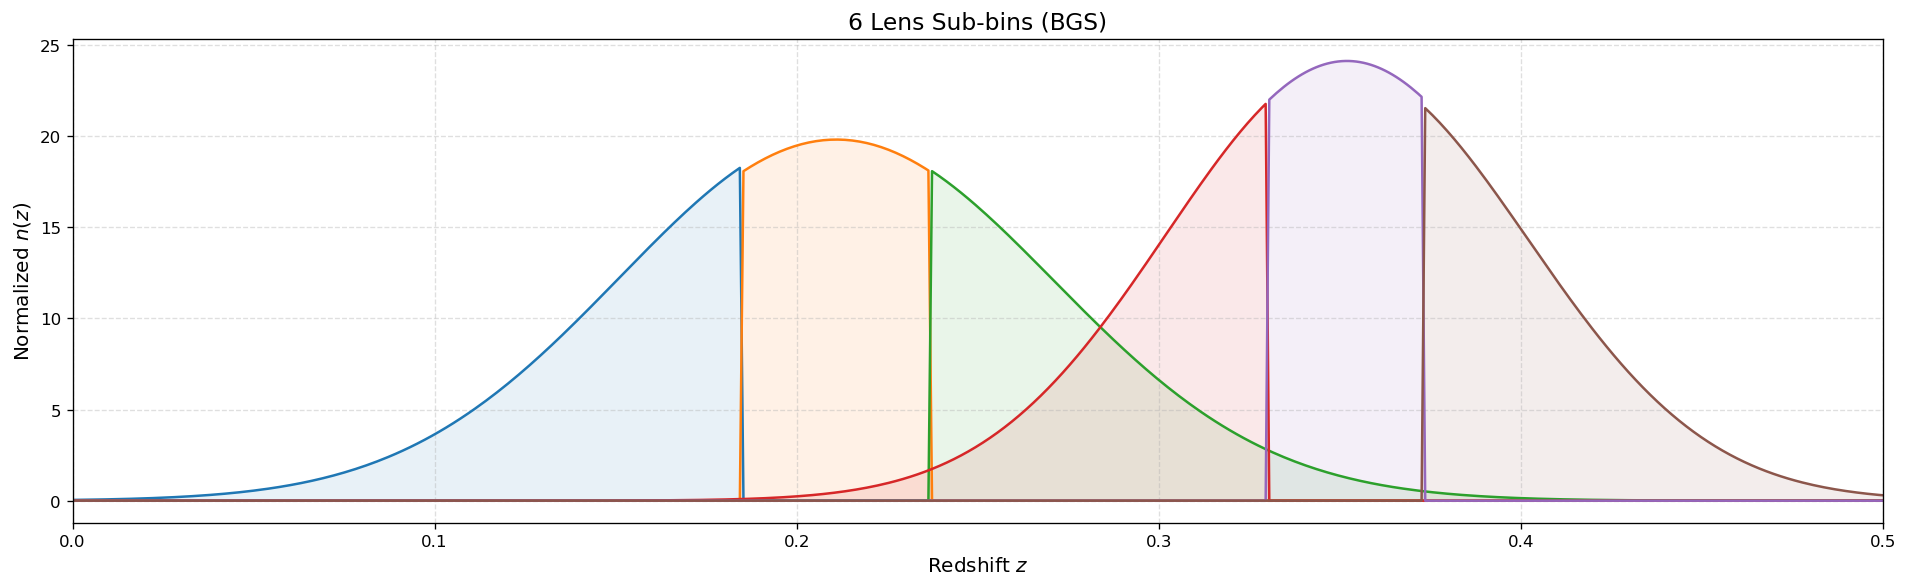

In [47]:
fig, axes = plt.subplots(1, 1, figsize=(16, 5), dpi=120)

# 1. Plot 10 Lens Sub-bins (BGS)
z_lens = bgs_6bins_array[:, 0]
for i in range(1, bgs_6bins_array.shape[1]):
    axes.plot(z_lens, bgs_6bins_array[:, i], lw=1.5, label=f"Bin {i}")
    axes.fill_between(z_lens, bgs_6bins_array[:, i], alpha=0.1)

axes.set_title("6 Lens Sub-bins (BGS)", fontsize=14)
axes.set_xlabel("Redshift $z$", fontsize=12)
axes.set_ylabel("Normalized $n(z)$", fontsize=12)
axes.set_xlim(0.0, 0.5)
axes.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

In [48]:
# the shot and shape noise are proportional to 1/n_g, so if n_g for each bin is cut in three, then noise for each bin should be trippled
BGS_shot_noise = np.array([4.63 * (10 ** -7), 9.18 * (10 ** -7)])
BGS_shot_noise_6 = np.repeat(BGS_shot_noise * 3, 3)

print(BGS_shot_noise)
print(BGS_shot_noise_6)

[4.63e-07 9.18e-07]
[1.389e-06 1.389e-06 1.389e-06 2.754e-06 2.754e-06 2.754e-06]


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3190\pm 0.0050$ | $\Omega_m = 0.3190^{+0.0098}_{-0.0097}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3189\pm 0.0050$ | $\Omega_m = 0.3189^{+0.0098}_{-0.0098}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0046$ | $h = 0.6674^{+0.0090}_{-0.0090}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0046$ | $h = 0.6674^{+0.0091}_{-0.0090}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.039$ | $w_0 = -0.752^{+0.076}_{-0.076}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.039$ | $w_0 = -0.752^{+0.076}_{-0.076}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.16$ | $w_a = -0.86^{+0.32}_{-0.32}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.32}_{-0.32}$ |
| --- | --- | --- | --- |

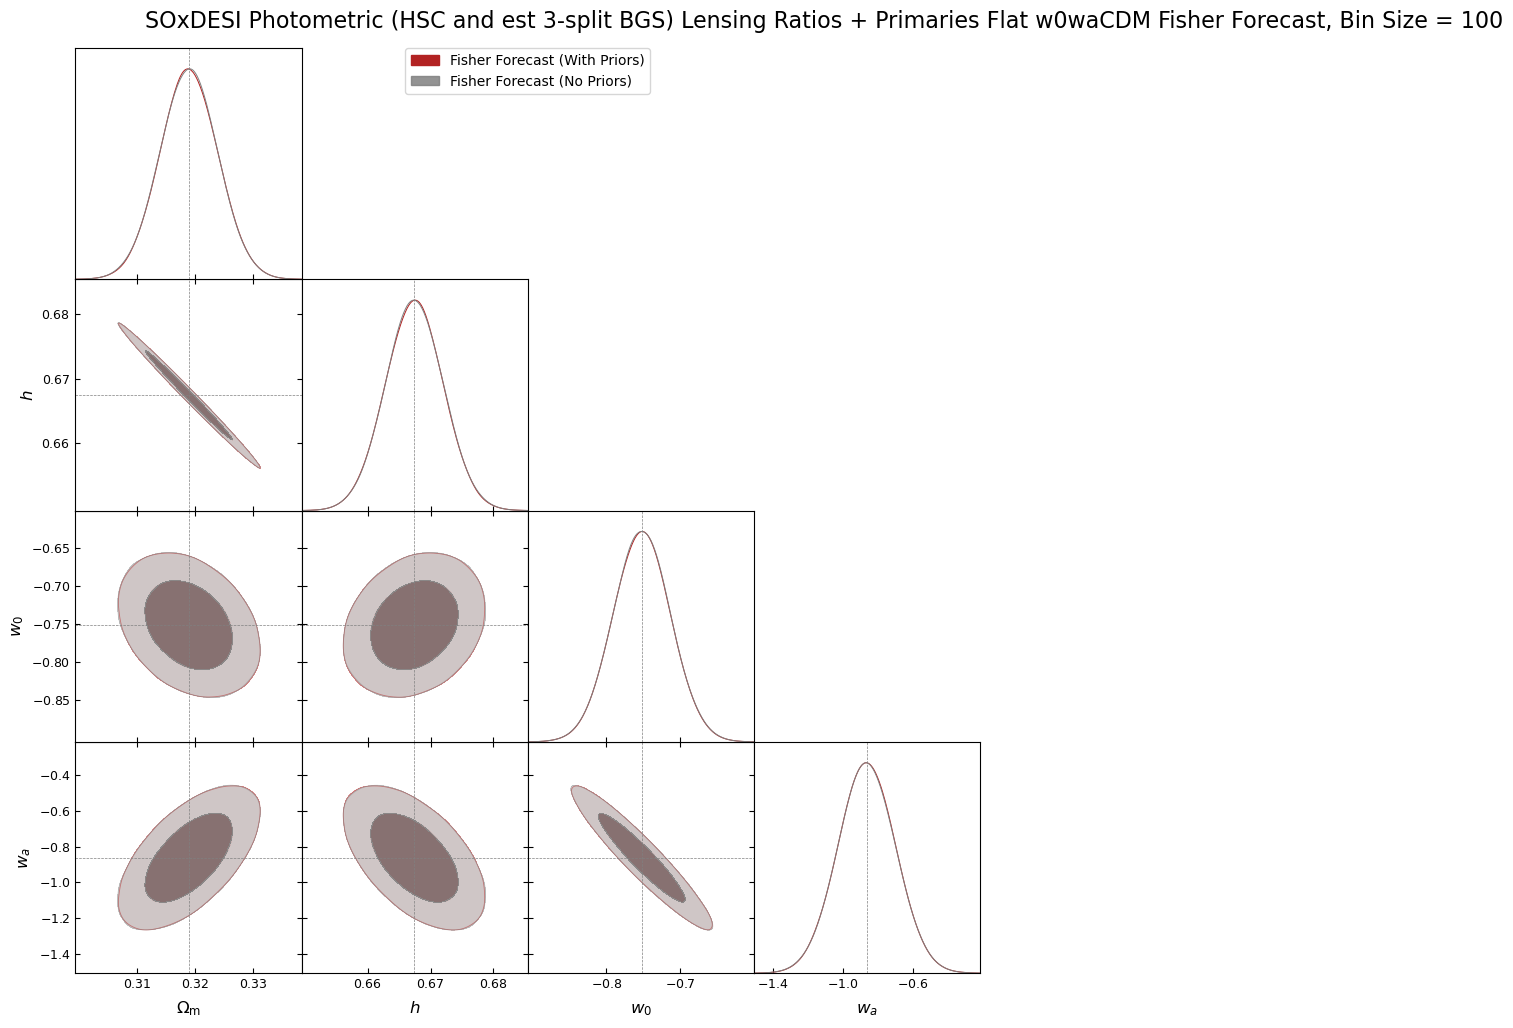

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2676\pm 0.0043$ | $\Omega_{c} = 0.2676^{+0.0084}_{-0.0084}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2676\pm 0.0043$ | $\Omega_{c} = 0.2676^{+0.0084}_{-0.0085}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00069$ | $\Omega_{b} = 0.0499^{+0.0013}_{-0.0013}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00069$ | $\Omega_{b} = 0.0499^{+0.0013}_{-0.0013}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0046$ | $h = 0.6674^{+0.0090}_{-0.0090}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0046$ | $h = 0.6674^{+0.0091}_{-0.0090}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.039$ | $w_0 = -0.752^{+0.076}_{-0.076}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.039$ | $w_0 = -0.752^{+0.076}_{-0.076}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.16$ | $w_a = -0.86^{+0.32}_{-0.32}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.32}_{-0.32}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.0940\pm 0.0043\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0084}_{-0.0083}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.0940\pm 0.0042\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0083}_{-0.0083}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9654\pm 0.0024$ | $n_s = 0.9654^{+0.0046}_{-0.0046}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9654\pm 0.0024$ | $n_s = 0.9654^{+0.0046}_{-0.0046}$ |
| --- | --- | --- | --- |

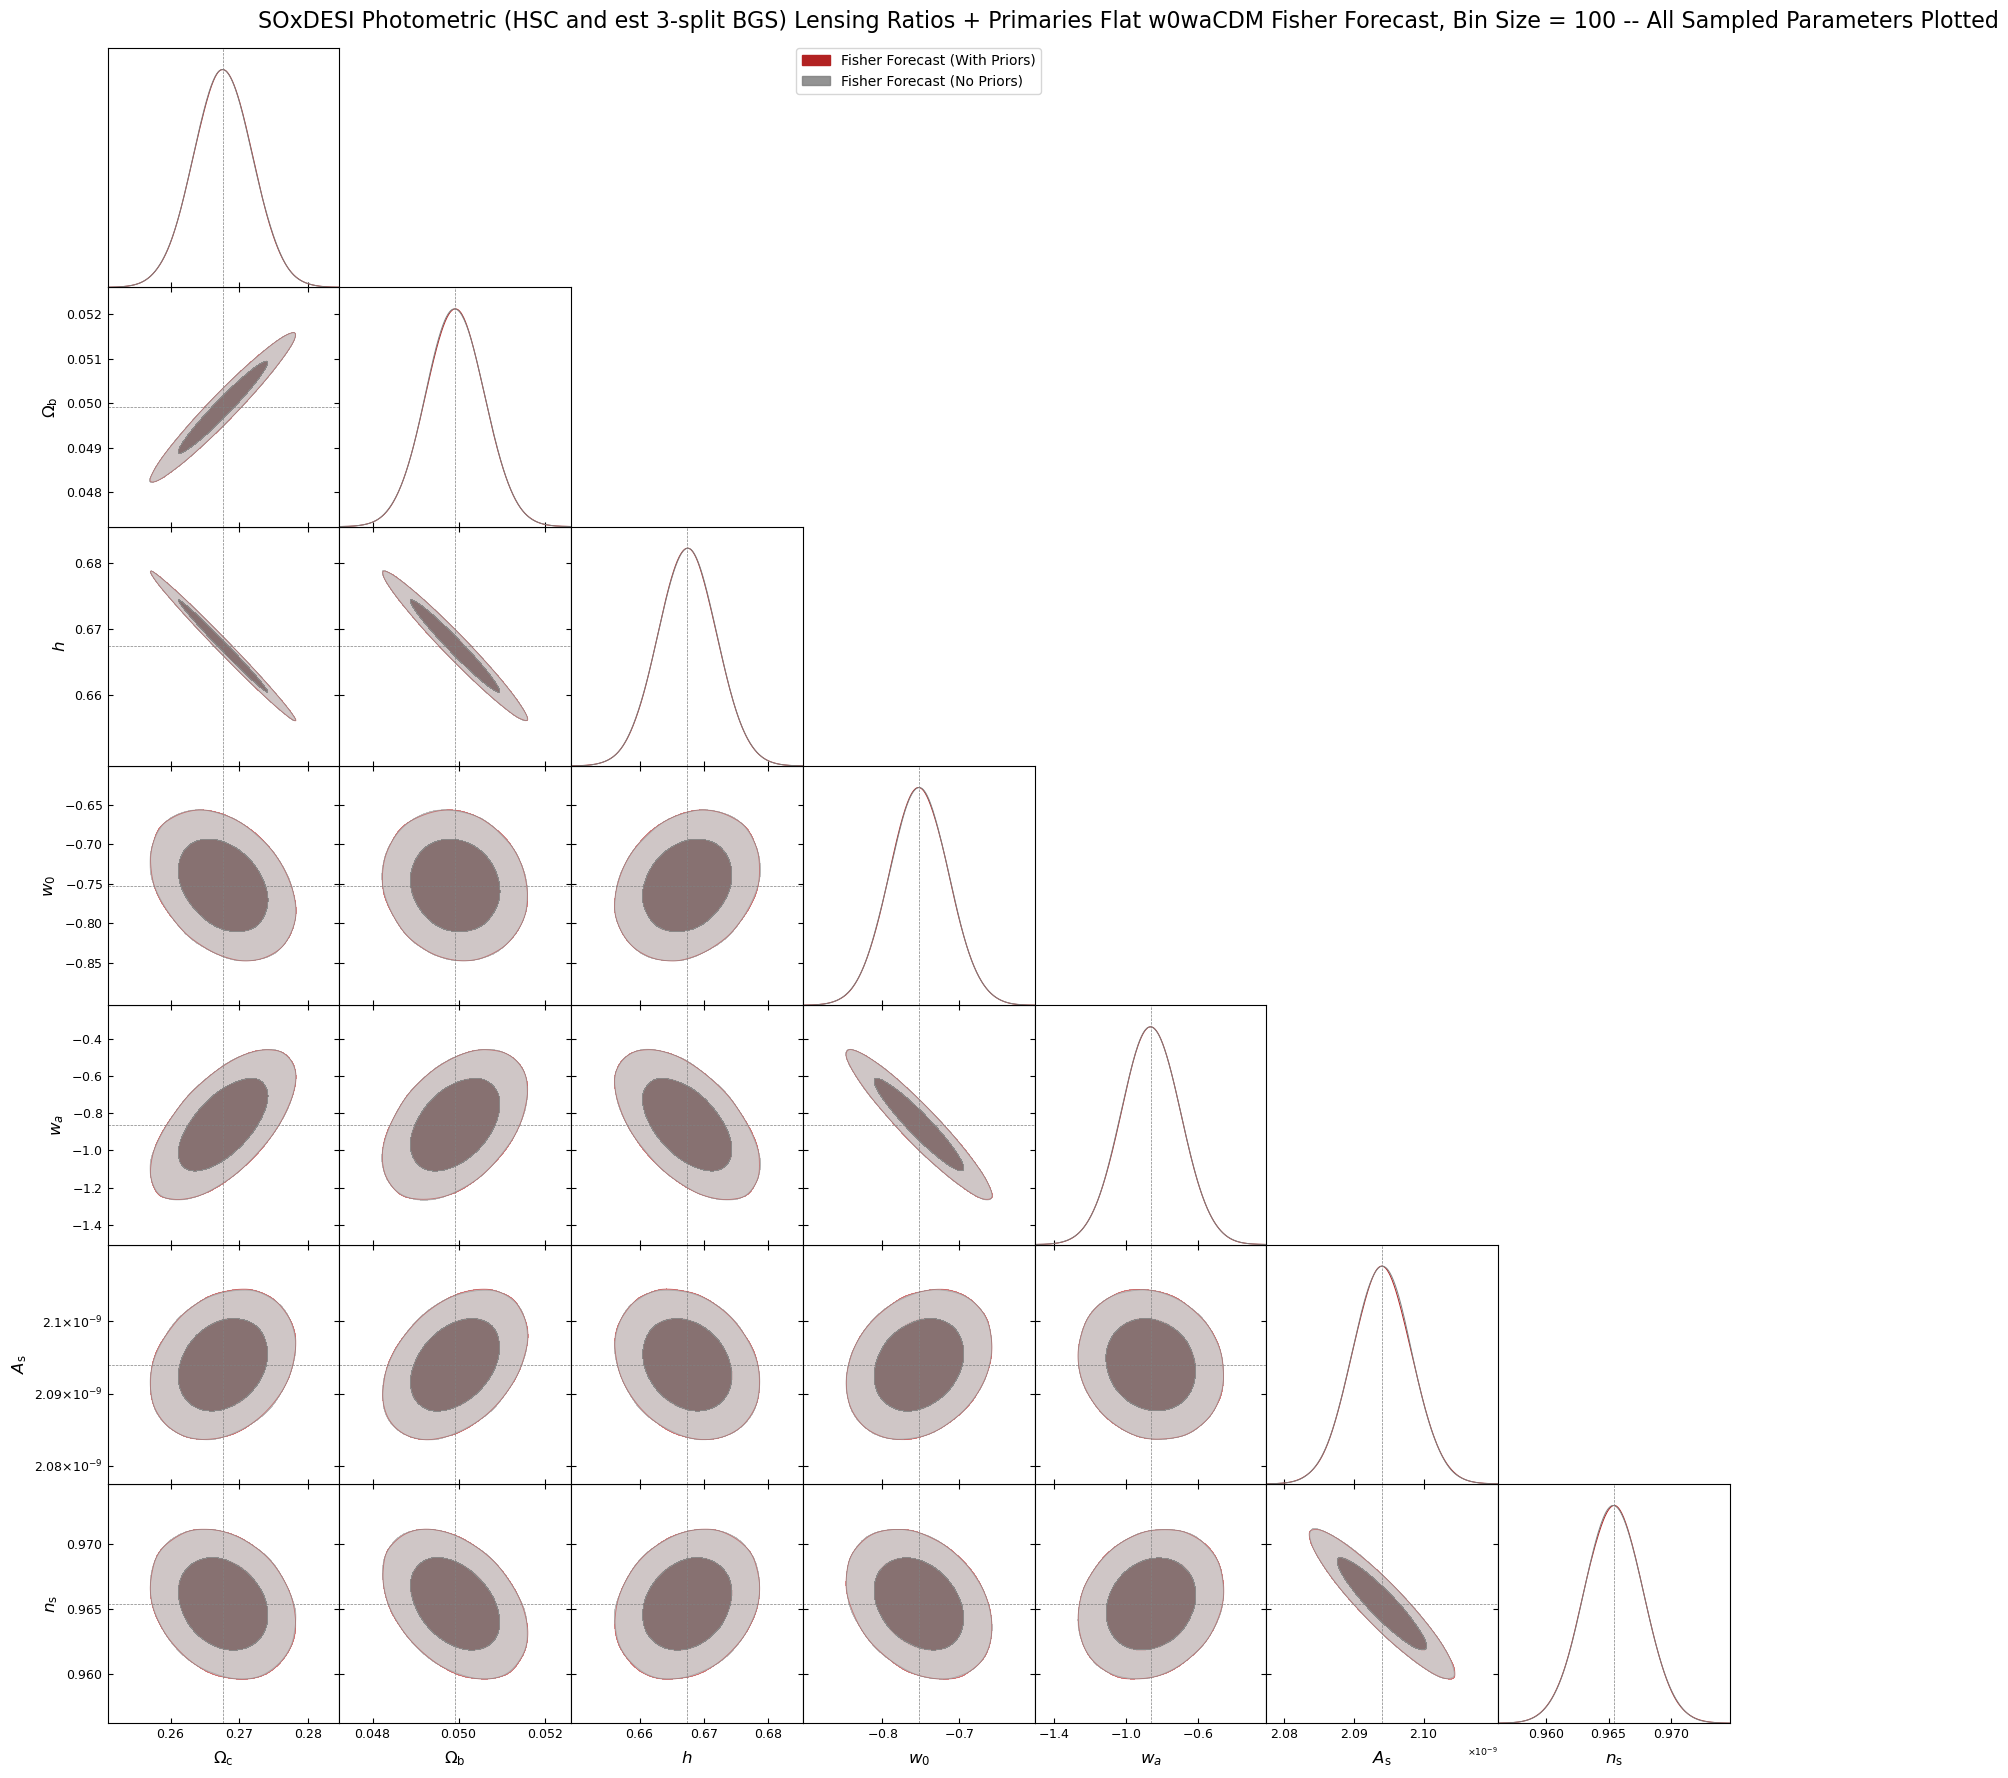

total_time:  0:14:01.308891


In [49]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=bgs_6bins_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_6,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_3Split_Photo_HSC_BGS_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_3Split_Photo_HSC_BGS_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (HSC and est 3-split BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (HSC and est 3-split BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 100 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_m$** | Fisher Forecast (With Priors) | $\Omega_m = 0.3189\pm 0.0050$ | $\Omega_m = 0.3189^{+0.0098}_{-0.0098}$ |
|  | Fisher Forecast (No Priors) | $\Omega_m = 0.3189\pm 0.0050$ | $\Omega_m = 0.3189^{+0.0097}_{-0.0098}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0046$ | $h = 0.6674^{+0.0091}_{-0.0090}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0046$ | $h = 0.6674^{+0.0090}_{-0.0090}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.039$ | $w_0 = -0.752^{+0.076}_{-0.076}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.039$ | $w_0 = -0.752^{+0.076}_{-0.076}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.32}_{-0.32}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.32}_{-0.32}$ |
| --- | --- | --- | --- |

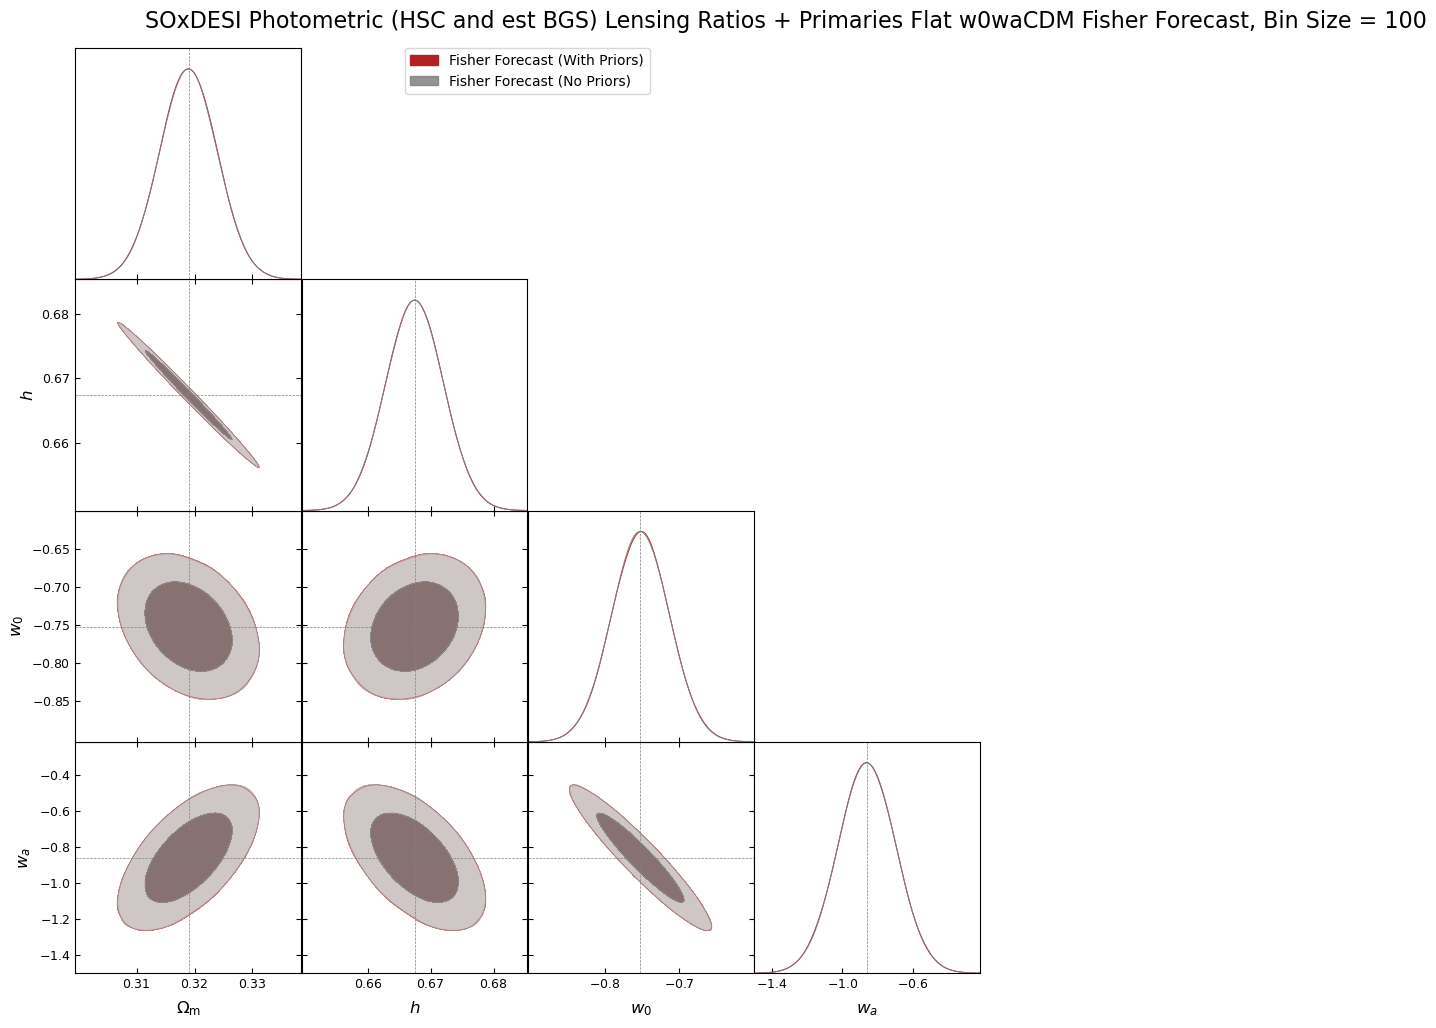

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


| Parameter | Dataset / Model | 1-Sigma (68%) | 2-Sigma (95%) |
| :--- | :--- | :---: | :---: |
| **$\Omega_{c}$** | Fisher Forecast (With Priors) | $\Omega_{c} = 0.2676\pm 0.0043$ | $\Omega_{c} = 0.2676^{+0.0084}_{-0.0084}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{c} = 0.2676\pm 0.0043$ | $\Omega_{c} = 0.2676^{+0.0084}_{-0.0084}$ |
| --- | --- | --- | --- |
| **$\Omega_{b}$** | Fisher Forecast (With Priors) | $\Omega_{b} = 0.04991\pm 0.00069$ | $\Omega_{b} = 0.0499^{+0.0013}_{-0.0013}$ |
|  | Fisher Forecast (No Priors) | $\Omega_{b} = 0.04991\pm 0.00069$ | $\Omega_{b} = 0.0499^{+0.0014}_{-0.0013}$ |
| --- | --- | --- | --- |
| **$h$** | Fisher Forecast (With Priors) | $h = 0.6674\pm 0.0046$ | $h = 0.6674^{+0.0091}_{-0.0090}$ |
|  | Fisher Forecast (No Priors) | $h = 0.6674\pm 0.0046$ | $h = 0.6674^{+0.0091}_{-0.0091}$ |
| --- | --- | --- | --- |
| **$w_0$** | Fisher Forecast (With Priors) | $w_0 = -0.752\pm 0.039$ | $w_0 = -0.752^{+0.076}_{-0.076}$ |
|  | Fisher Forecast (No Priors) | $w_0 = -0.752\pm 0.039$ | $w_0 = -0.752^{+0.077}_{-0.076}$ |
| --- | --- | --- | --- |
| **$w_a$** | Fisher Forecast (With Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.32}_{-0.32}$ |
|  | Fisher Forecast (No Priors) | $w_a = -0.86\pm 0.17$ | $w_a = -0.86^{+0.32}_{-0.33}$ |
| --- | --- | --- | --- |
| **$A_s$** | Fisher Forecast (With Priors) | $A_s = \left(\,2.0940\pm 0.0043\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0084}_{-0.0083}\,\right)\cdot 10^{-9}$ |
|  | Fisher Forecast (No Priors) | $A_s = \left(\,2.0940\pm 0.0043\,\right)\cdot 10^{-9}$ | $A_s = \left(\,2.0940^{+0.0083}_{-0.0083}\,\right)\cdot 10^{-9}$ |
| --- | --- | --- | --- |
| **$n_s$** | Fisher Forecast (With Priors) | $n_s = 0.9654\pm 0.0024$ | $n_s = 0.9654^{+0.0047}_{-0.0047}$ |
|  | Fisher Forecast (No Priors) | $n_s = 0.9654\pm 0.0024$ | $n_s = 0.9654^{+0.0046}_{-0.0046}$ |
| --- | --- | --- | --- |

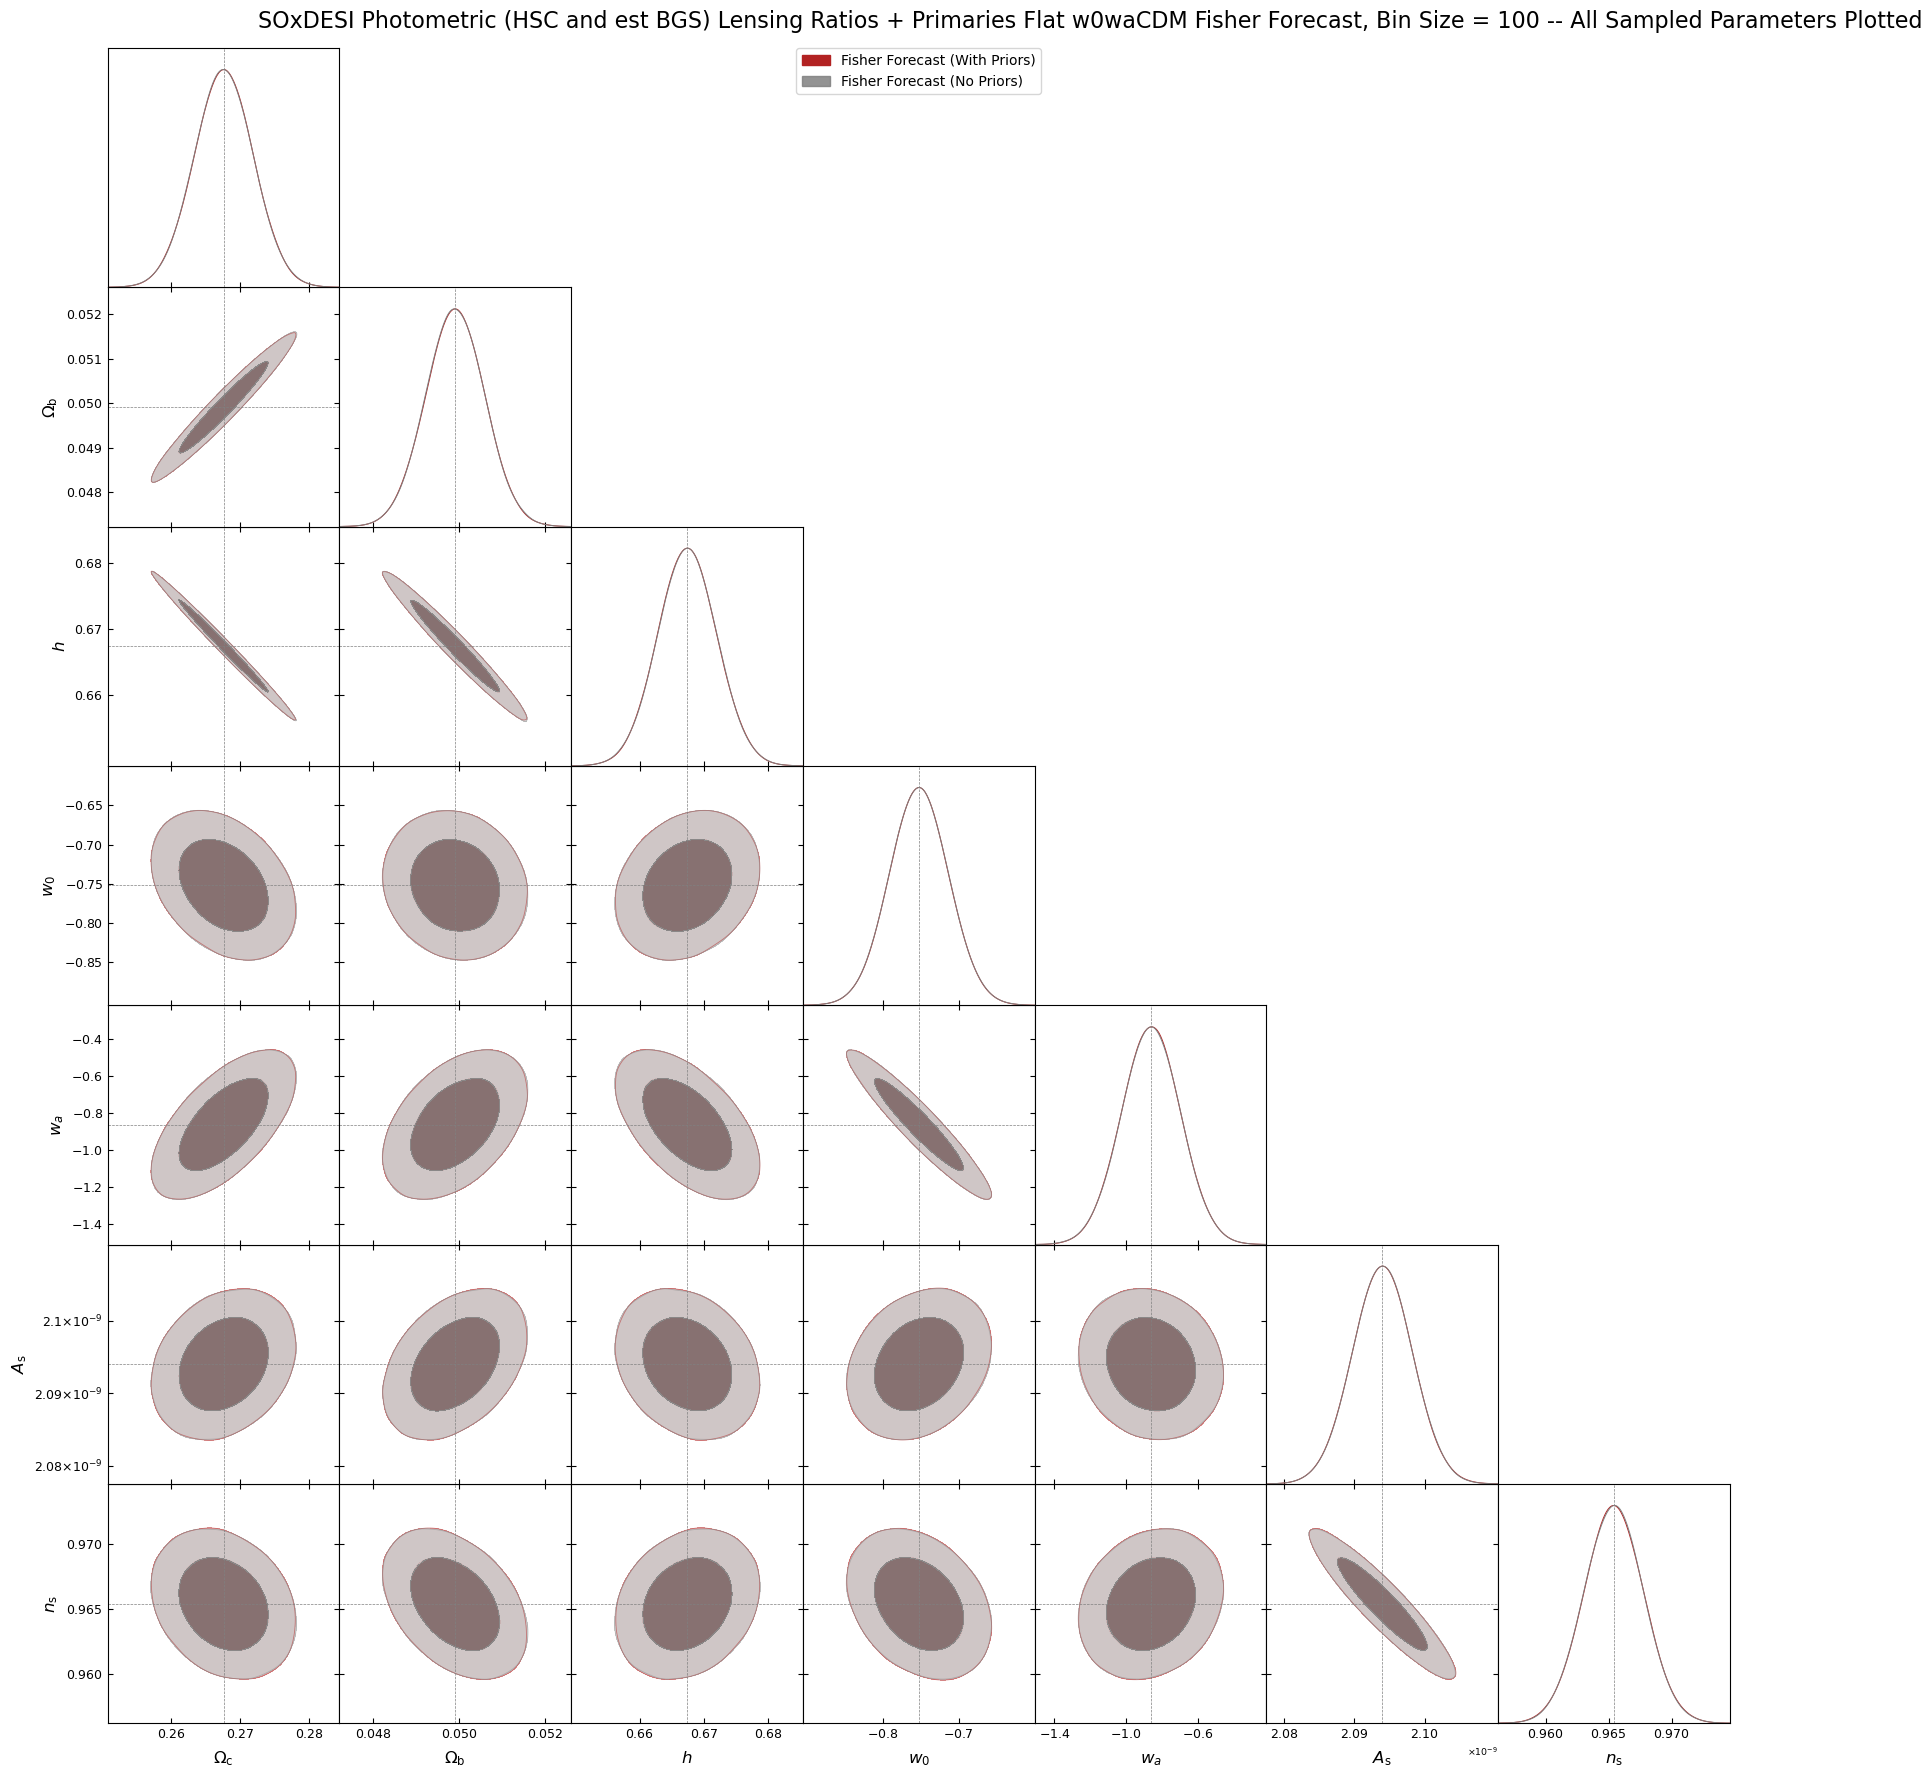

total_time:  0:14:02.296254


In [50]:
start_time = time.time()

# instantiate forecaster
forecaster_c1 = FisherForecaster(
    cosmology=flat_w0waCDM_cosmology,
    lens_data=bgs_6bins_array,
    source_data=HSC_dist_0_3,
    binsize=100,
    l_min =40,
    n_ell = 5000,
    f_sky = 0.4,
    magnification_bias_lenses = 0.8,
    linear_emulator = None,
    boost_emulator = None,
    cmb_noise_kk=SO_cmb_noise_kk,
    cmb_noise_TT=SO_goal_cmb_noise_TT,
    cmb_noise_EE=SO_goal_cmb_noise_EE,
    shot_noise_lens=BGS_shot_noise_6,
    shape_noise_source=HSC_shape_noise,
    desired_spectra=['CG', 'GL', 'TT', 'EE'],
    cmb_primaries=True,
    z_max=6,
    n_chi=1024
)

# list of all parameters being analyzed
params_to_sample = ['Omega_c', 'Omega_b', 'h', 'w0', 'wa', 'A_s', 'n_s']
params_to_plot = ['Omega_m', 'h', 'w0', 'wa']

# compute the raw data-only Fisher matrix (populates internally for sampling)
F_raw_c1, cov_raw_c1 = forecaster_c1.make_fisher_matrix(desired_params=params_to_sample)

# save matrices
np.savetxt(
    'Fisher Forecasts/Fisher Matrices/Flat_w0waCDM_LRP_Photo_HSC_BGS_Binsize=100.txt', 
    F_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)
np.savetxt(
    'Fisher Forecasts/Covariance Matrices/Flat_w0waCDM_LRP_Photo_HSC_BGS_Binsize=100.txt', 
    cov_raw_c1, 
    header='Omega_c Omega_b h w0 wa A_s n_s',
    comments='# Fiducial parameters: Omega_c, Omega_b, h, w0, wa, A_s, n_s\n'
)

# Call the unified class method to load, sample, overlay, and plot everything
g = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (HSC and est BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 100",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_plot,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

g2 = forecaster_c1.plot_with_cobaya_overlay(
    title="SOxDESI Photometric (HSC and est BGS) Lensing Ratios + Primaries Flat w0waCDM Fisher Forecast, Bin Size = 100 -- All Sampled Parameters Plotted",
    cobaya_chain_dir=None,
    uniform_priors=uniform_prior,
    plot_params=params_to_sample,
    overlay_priorless=True,
    save_plot = False,
    print_summary = True,
    plot_prior = False
)

plt.show()

end_time = time.time()
total_time = end_time - start_time
total_time = datetime.timedelta(seconds=total_time)
print("total_time: ", total_time)

# Cobaya MCMC

1.  **Parameters**: The cosmological parameters we want to constrain (e.g., $\Omega_m$, $\sigma_8$, $h$).
2.  **Likelihood**: A Python class that calculates the log-likelihood $L(\mathbf{D}|\mathbf{\theta})$, where $\mathbf{D}$ is the data vector and $\mathbf{\theta}$ are the cosmological parameters. For a Gaussian likelihood, this involves comparing a theoretical model (based on $\mathbf{\theta}$) to an observed data vector (which we'll treat as a fiducial model with noise) and using a covariance matrix.
3.  **Prior**: The prior distributions for our parameters.
4.  **Sampler**: The MCMC algorithm Cobaya will use to explore the parameter space.

### Likelihood

$$\ln L = -\frac{1}{2} (\mathbf{D} - \mathbf{M}(\mathbf{\theta}))^T \mathbf{C}^{-1} (\mathbf{D} - \mathbf{M}(\mathbf{\theta})) - \frac{1}{2} \ln |\mathbf{C}|$$

where:
*   $\mathbf{D}$ is the 'observed' data vector (derived from a fiducial cosmology with noise).
*   $\mathbf{M}(\mathbf{\theta})$ is the model prediction for the data vector, calculated using the given cosmological parameters $\mathbf{\theta}$.
*   $\mathbf{C}$ is the covariance matrix.

We already have the infrastructure to build the covariance matrix and calculate the theoretical $C_\ell$ values for a given cosmology. Now, we need to wrap this logic into a Cobaya-compatible likelihood class.

### Parameters and Sampler

**Parameters (params section):**

*   **prior**: The prior distribution for the parameter (e.g., min/max for a flat prior, loc/scale for a Gaussian).
*   **ref**: A reference value, often used by samplers to initiate chains or define a starting point.
*   **proposal**: The width of the proposal distribution for the sampler (how much the parameter changes in each step).
*   **latex**: A LaTeX representation for plotting and reporting.

**Sampler (sampler section):**

*   **Rminus1_stop**: A convergence criterion (Gelman-Rubin statistic minus 1). Smaller values indicate better convergence.
*   **max_samples**: The maximum number of samples to generate.

In [ ]:
# Cobaya in NERSC Configured Job
# 1 node, 4 tasks per node, 64 CPUs per task
# syntax example below

In [ ]:
cd $SCRATCH
module load python
conda activate cosmo311
cd ~/DESIxSO

rm -rf /pscratch/sd/l/lialubit/run_task_*

export COBAYA_USE_FILE_LOCKING=False
export OMP_NUM_THREADS=64
export OMP_PLACES=threads
export OMP_PROC_BIND=spread

time srun -n 4 -c 64 --cpu_bind=cores bash -c '
export PYTHONPATH="${HOME}/DESIxSO:${PYTHONPATH}"
TASK_YAML="run_config_${SLURM_PROCID}.yaml"
cp yaml/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood.yaml $TASK_YAML
MY_SEED=$((1234 + SLURM_PROCID))
sed -i "s/seed:.*/seed: ${MY_SEED}/g" $TASK_YAML
$(which cobaya-run) $TASK_YAML -o /pscratch/sd/l/lialubit/run_task_${SLURM_PROCID}/chain
rm -f $TASK_YAML
'

In [ ]:
CHAIN_DEST="chains/flat_LCDM_bin1_LRP_omega_c_omega_b_likelihood_INCOMPLETE2"
mkdir -p $CHAIN_DEST

for i in {0..3}; do
    cp /pscratch/sd/l/lialubit/run_task_${i}/chain.1.txt $CHAIN_DEST/chain_task_${i}.txt
    ln -sf chain_task_${i}.txt $CHAIN_DEST/cosmo_run.${i}.txt
done

# Copy the paramnames file so your plotting code works immediately
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/chain_task.paramnames
cp /pscratch/sd/l/lialubit/run_task_0/chain.paramnames $CHAIN_DEST/cosmo_run.paramnames